# Market Regime Detection via Hidden Markov Model (HMM)

Unsupervised regime detection using `hmmlearn.GaussianHMM`.

**Features used:**
- Daily log-returns
- Rolling volatility (20-day std of log-returns)
- Yang-Zhang volatility (20-day, annualised OHLC)
- Rolling momentum (20-day)
- Volume ratio (relative to 20-day avg)

**Regimes (n_components=3):** Bear / Neutral / Bull (labelled by mean return)

In [75]:
# ── dependencies ──────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap
import seaborn as sns

from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm

plt.style.use('dark_background')
sns.set_palette('husl')
print('imports ok')

imports ok


## 1. Load Data

In [76]:
# ── load from DeltaLake (S3/MinIO) with local HDF5 fallback ──────────────────
import os, pathlib

HDF5_PATH = pathlib.Path('stocks_data_latest.h5')
S3_ENDPOINT = 'http://192.168.1.30:9000'
S3_TABLE    = 's3://delta-table-storage/stocks'
SYMBOL      = 'VNINDEX'   # benchmark index; change to any symbol in watchlist
YEARS_BACK  = 10

def load_from_delta():
    import deltalake as dl
    storage_opts = {
        'AWS_ACCESS_KEY_ID':     os.environ.get('MINIO_ACCESS_KEY', 'CzOwnLkEDXQy951AOqes'),
        'AWS_SECRET_ACCESS_KEY': os.environ.get('MINIO_SECRET_KEY', 'fdRe91TOtqTl0icUkZLsUnWvZa90aZ5qG5rVEf7S'),
        'AWS_ENDPOINT_URL':      S3_ENDPOINT,
        'AWS_ALLOW_HTTP':        'true',
        'AWS_S3_ALLOW_UNSAFE_RENAME': 'true',
    }
    tbl = dl.DeltaTable(S3_TABLE, storage_options=storage_opts)
    df  = tbl.to_pandas()
    df['date'] = pd.to_datetime(df['date'])
    return df

def load_from_hdf5():
    with pd.HDFStore(HDF5_PATH, 'r') as store:
        df = store['stocks']
    # Wide panel uses DatetimeIndex; reset_index() would move date into a column and
    # .loc[:, symbol_cols] would drop it — index becomes 0..n and dates "disappear".
    if isinstance(df.index, pd.DatetimeIndex):
        return df.sort_index()
    if isinstance(df.index, pd.MultiIndex):
        return df
    df = df.reset_index()
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df = df.set_index('date').sort_index()
    return df

# --- try delta first, fall back to hdf5 ---
try:
    print('Loading from DeltaLake …')
    raw = load_from_hdf5()
    print(f'  DeltaLake OK — {len(raw):,} rows')
except Exception as e:
    print(f'  DeltaLake failed ({e}), falling back to HDF5 …')
    raw = load_from_hdf5()
    print(f'  HDF5 OK — {len(raw):,} rows')


# Build single-symbol OHLCV frame for strategy development
SYMBOL = "VNINDEX"  # change to any symbol in watchlist

# df columns are MultiIndex: (field, symbol)
df_sym = raw.xs(SYMBOL, axis=1, level='symbol').copy()
df_sym = df_sym[["open", "high", "low", "close", "volume"]].dropna().copy()
df_sym.index = pd.to_datetime(df_sym.index)
df_sym = df_sym[~df_sym.index.duplicated(keep='last')].sort_index()
print(f'Symbol: {SYMBOL}  |  rows: {len(df_sym)}  |  {df_sym.index[0].date()} → {df_sym.index[-1].date()}')


Loading from DeltaLake …
  DeltaLake OK — 2,498 rows
Symbol: VNINDEX  |  rows: 2498  |  2016-05-26 → 2026-05-22


## 2. Feature Engineering

In [77]:
W = 20  # rolling window


def yang_zhang_vol(open_, high, low, close, window=20):
    """Yang-Zhang volatility (annualised). Uses OHLC; handles overnight gaps."""
    rs = (np.log(high / close) * np.log(high / open_) +
          np.log(low  / close) * np.log(low  / open_))
    log_co = np.log(open_ / close.shift(1))
    log_oc = np.log(close / open_)
    k = 0.34 / (1.34 + (window + 1) / (window - 1))
    yz_var = (log_co.rolling(window).var()
              + k * log_oc.rolling(window).var()
              + (1 - k) * rs.rolling(window).mean())
    return np.sqrt(yz_var.clip(lower=0) * 252)


feat = pd.DataFrame(index=df_sym.index)

# log-return
feat['log_ret']    = np.log(df_sym['close'] / df_sym['close'].shift(1))

# realised volatility (rolling std of log-returns)
feat['volatility'] = feat['log_ret'].rolling(W).std()

# Yang-Zhang volatility (annualised)
feat['yang_zhang_vol'] = yang_zhang_vol(
    df_sym['open'], df_sym['high'], df_sym['low'], df_sym['close'], window=W)

# momentum (log return over W days)
feat['momentum']   = np.log(df_sym['close'] / df_sym['close'].shift(W))

# volume ratio (today / W-day avg)
feat['vol_ratio']  = df_sym['volume'] / df_sym['volume'].rolling(W).mean()

feat = feat.dropna()
print(f'Feature matrix: {feat.shape}  |  {feat.index[0].date()} → {feat.index[-1].date()}')
feat.describe().round(4)

Feature matrix: (2478, 5)  |  2016-06-23 → 2026-05-22


,log_ret,volatility,yang_zhang_vol,momentum,vol_ratio
count,2478.0000,2478.0000,2478.0000,2478.0000,2478.0000
mean,0.0004,0.0105,0.1577,0.0090,1.0126
std,0.0119,0.0055,0.0749,0.0580,0.2269
min,-0.0691,0.0030,0.0514,-0.3220,0.3120
25%,-0.0042,0.0065,0.1016,-0.0161,0.8558
50%,0.0014,0.0087,0.1421,0.0138,0.9911
75%,0.0064,0.0133,0.1929,0.0436,1.1272
max,0.0655,0.0331,0.5134,0.1593,2.1959


## 3. Fit GaussianHMM

In [78]:
N_REGIMES   = 3      # Bear / Neutral / Bull
N_ITER      = 200
RANDOM_SEED = 42

FEATURE_COLS = ['log_ret', 'volatility', 'yang_zhang_vol', 'momentum', 'vol_ratio']

scaler = StandardScaler()
X      = scaler.fit_transform(feat[FEATURE_COLS].values)

model = GaussianHMM(
    n_components=N_REGIMES,
    covariance_type='full',
    n_iter=N_ITER,
    random_state=RANDOM_SEED,
    tol=1e-4,
)
model.fit(X)
print(f'Converged: {model.monitor_.converged}  |  log-likelihood: {model.score(X):.2f}')

hidden_states = model.predict(X)
state_probs   = model.predict_proba(X)   # shape (T, n_regimes)

feat['state'] = hidden_states

Converged: True  |  log-likelihood: -10304.63


In [79]:
# ── label states by mean log-return (lowest=Bear, highest=Bull) ──────────────
state_mean_ret = {
    s: feat.loc[feat['state'] == s, 'log_ret'].mean()
    for s in range(N_REGIMES)
}
ranked = sorted(state_mean_ret, key=state_mean_ret.get)
label_map   = {ranked[0]: 'Bear',    ranked[1]: 'Neutral', ranked[2]: 'Bull'}
color_map   = {ranked[0]: '#e74c3c', ranked[1]: '#f39c12', ranked[2]: '#2ecc71'}

feat['regime'] = feat['state'].map(label_map)

for s in ranked:
    sub = feat[feat['state'] == s]
    print(f"State {s} → {label_map[s]:7s}  "
          f"mean_ret={state_mean_ret[s]*100:.3f}%  "
          f"count={len(sub)}  frac={len(sub)/len(feat):.1%}")

State 2 → Bear     mean_ret=-0.136%  count=563  frac=22.7%
State 1 → Neutral  mean_ret=0.096%  count=883  frac=35.6%
State 0 → Bull     mean_ret=0.099%  count=1032  frac=41.6%


## 3b. Regime-Switching Kalman Filter (main HMM)

Layer 2 on the **3-state return HMM** (§3): HMM posteriors weight three parallel
1D Kalman filters tracking **Yang–Zhang vol**. Per-regime `Q`/`R` scale with that
state's typical vol (stable Bear/Neutral/Bull filters vs fast-tracking in high-vol states).

| Output | Meaning |
|--------|--------|
| `kv` | Probability-weighted Kalman vol estimate |
| `ku` / `kl` | ±1.5σ mixture band (widens when HMM is uncertain) |
| `kg` | Blended Kalman gain |
| `reg` | Dominant regime index (Bear=0 … Bull=2 in `ranked` order) |


In [80]:
# ── reorder HMM posteriors: Bear → Neutral → Bull ─────────────────────────
hmm_probs_ord = state_probs[:, ranked]   # (T, 3)

state_mean_yz = {
    s: feat.loc[feat['state'] == s, 'yang_zhang_vol'].mean()
    for s in range(N_REGIMES)
}
yz_by_vol = sorted(state_mean_yz, key=state_mean_yz.get)   # low → high vol states
Q_TIERS = [6e-4, 20e-4, 100e-4]
R_TIERS = [6e-4, 20e-4, 100e-4]
vol_tier = {s: yz_by_vol.index(s) for s in range(N_REGIMES)}

KF_Q = [Q_TIERS[vol_tier[s]] for s in ranked]
KF_R = [R_TIERS[vol_tier[s]] for s in ranked]
mu_init = [state_mean_yz[s] for s in ranked]
P_init  = list(KF_Q)

print('Per-regime YZ vol (init μ) and KF noise:')
for i, s in enumerate(ranked):
    print(f"  {label_map[s]:7s}  μ={state_mean_yz[s]*100:.1f}%  Q={KF_Q[i]:.1e}  R={KF_R[i]:.1e}")


def regime_switching_kalman(obs, probs, Q, R, mu0, P0, index=None):
    """Per-regime 1D KF + HMM-weighted mixture (causal filtering)."""
    K = len(Q)
    mu = list(mu0)
    P = list(P0)
    rows = []

    for t, o in enumerate(obs):
        w = probs[t]
        mu2, P2, Kg = [], [], []

        for k in range(K):
            Pp = P[k] + Q[k]
            G = Pp / (Pp + R[k])
            Kg.append(G)
            mu2.append(mu[k] + G * (o - mu[k]))
            P2.append((1 - G) * Pp)

        mMu = sum(w[k] * mu2[k] for k in range(K))
        mVar = sum(w[k] * (P2[k] + (mu2[k] - mMu) ** 2) for k in range(K))
        mStd = np.sqrt(max(0.0, mVar))
        mKg = sum(w[k] * Kg[k] for k in range(K))
        dom = int(np.argmax(w))

        mu = mu2
        P = P2
        rows.append({
            'kv': mMu,
            'ku': min(0.80, mMu + 1.5 * mStd),
            'kl': max(0.00, mMu - 1.5 * mStd),
            'kg': mKg,
            'reg': dom,
        })

    if index is None:
        index = pd.RangeIndex(len(rows))
    return pd.DataFrame(rows, index=index)


hmm_kf = regime_switching_kalman(
    feat['yang_zhang_vol'].values,
    hmm_probs_ord,
    KF_Q, KF_R, mu_init, P_init,
    index=feat.index,
)
feat['kf_regime'] = [label_map[ranked[int(r)]] for r in hmm_kf['reg']]

tail = hmm_kf.tail().copy()
for col in ['kv', 'ku', 'kl']:
    tail[col] = (tail[col] * 100).round(2)
print('\nHMM-RSKF (last 5 rows):')
print(tail[['kv', 'kl', 'ku', 'kg', 'reg']])
print(f"Latest regime: {feat['kf_regime'].iloc[-1]}  |  Kalman σ = {hmm_kf['kv'].iloc[-1]*100:.2f}%")


Per-regime YZ vol (init μ) and KF noise:
  Bear     μ=26.3%  Q=1.0e-02  R=1.0e-02
  Neutral  μ=16.2%  Q=2.0e-03  R=2.0e-03
  Bull     μ=9.6%  Q=6.0e-04  R=6.0e-04

HMM-RSKF (last 5 rows):
               kv     kl     ku        kg  reg
date                                          
2026-05-18  18.69  13.42  23.96  0.618034    1
2026-05-19  18.76  13.48  24.03  0.618034    1
2026-05-20  19.79  14.52  25.07  0.618034    1
2026-05-21  20.10  14.82  25.37  0.618034    1
2026-05-22  20.31  15.03  25.59  0.618034    1
Latest regime: Neutral  |  Kalman σ = 20.31%


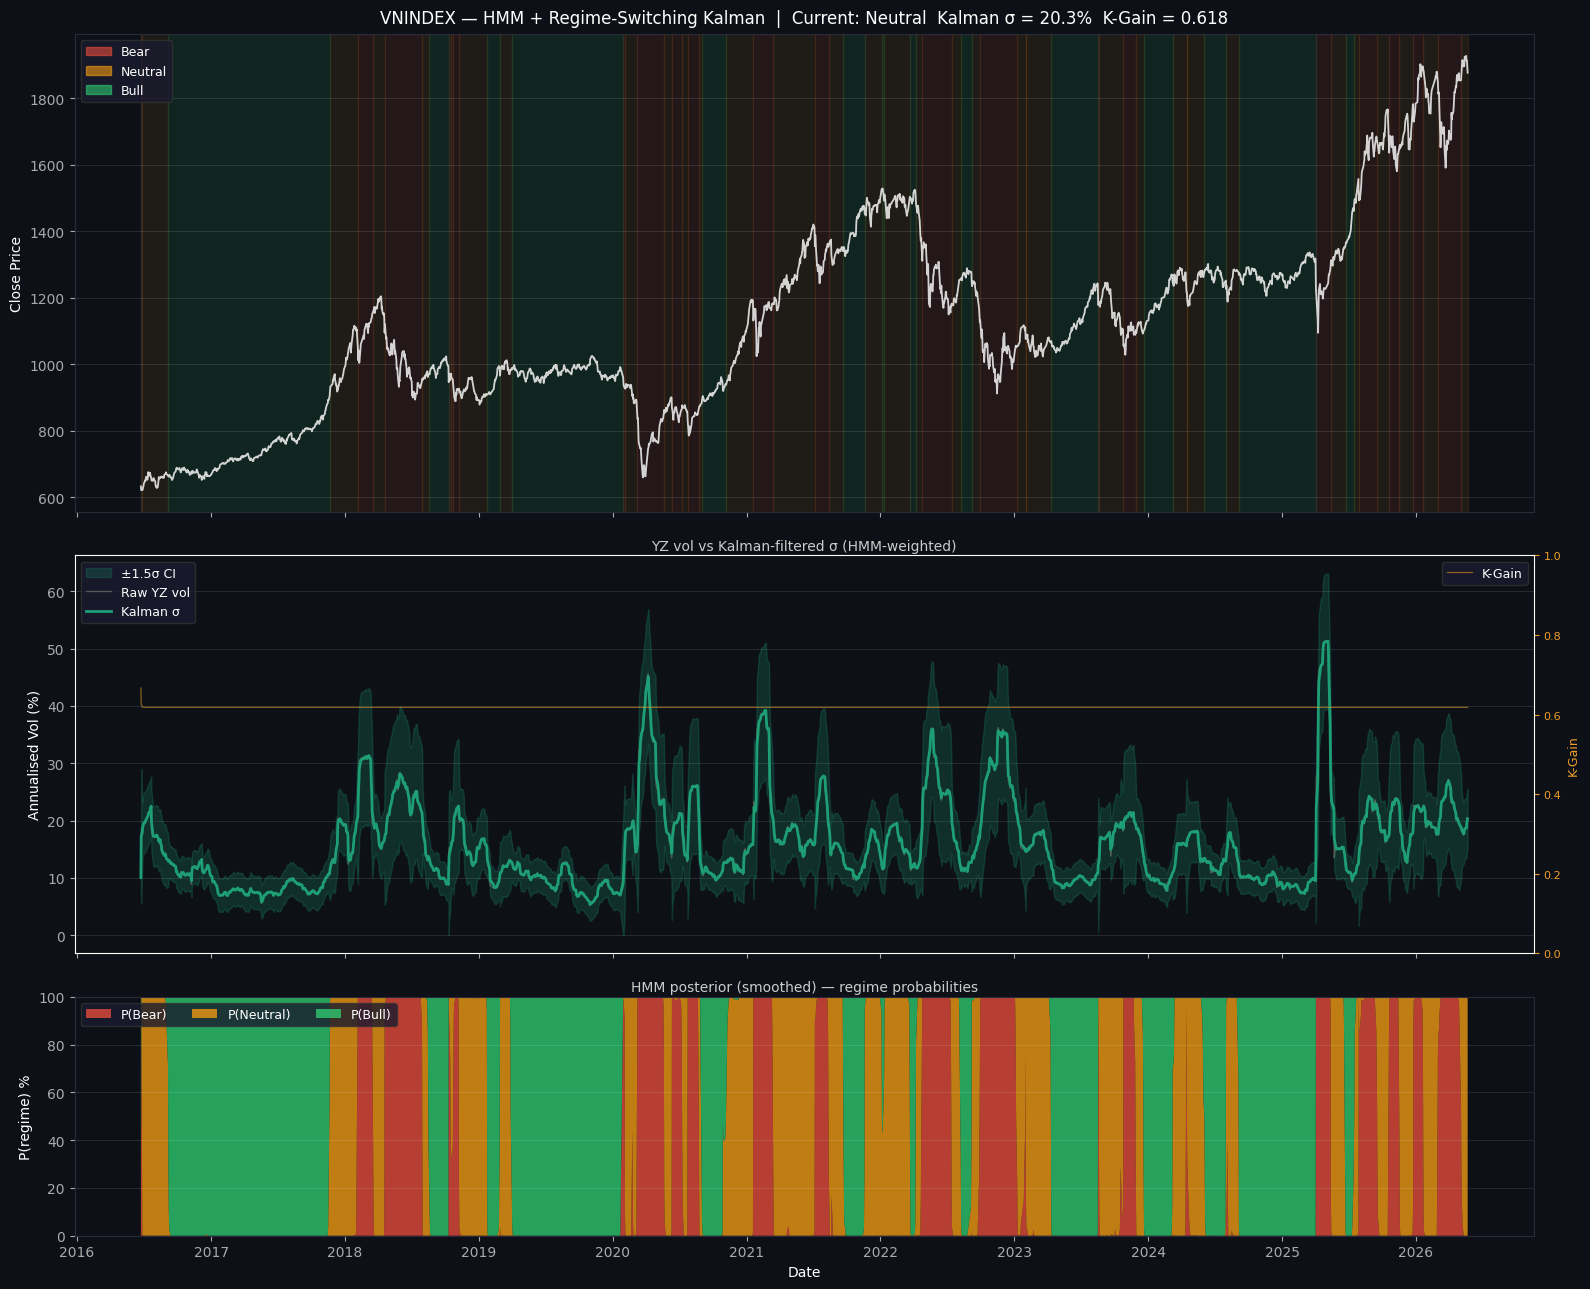

In [81]:
# ── three-panel: price / Kalman vol / HMM posteriors ────────────────────────
REGIME_NAMES = [label_map[s] for s in ranked]
REGIME_FILL  = [color_map[s] for s in ranked]
REGIME_ALPHA = [0.10, 0.08, 0.10]

dates = feat.index
close_s = df_sym.loc[dates, 'close']
yz_pct = feat['yang_zhang_vol'] * 100
kv_pct = hmm_kf['kv'] * 100
ku_pct = hmm_kf['ku'] * 100
kl_pct = hmm_kf['kl'] * 100
last = hmm_kf.iloc[-1]
cur_reg = int(last['reg'])

fig, axes = plt.subplots(
    3, 1, figsize=(16, 13),
    gridspec_kw={'height_ratios': [3, 2.5, 1.5]},
    sharex=True,
)
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#0d1117')
    ax.yaxis.grid(True, alpha=0.15, color='white', lw=0.5)
    ax.spines[:].set_color('#2a2a3a')

ax1 = axes[0]
prev_i, prev_r = dates[0], int(hmm_kf['reg'].iloc[0])
for i in range(1, len(dates)):
    cr = int(hmm_kf['reg'].iloc[i])
    if cr != prev_r or i == len(dates) - 1:
        ax1.axvspan(prev_i, dates[i], alpha=REGIME_ALPHA[prev_r],
                    color=REGIME_FILL[prev_r], zorder=1)
        prev_i, prev_r = dates[i], cr
ax1.plot(dates, close_s.values, color='#e8e8e8', lw=1.3, alpha=0.9, zorder=5)
ax1.set_ylabel('Close Price', fontsize=10)
ax1.set_title(
    f'{SYMBOL} — HMM + Regime-Switching Kalman  |  '
    f'Current: {REGIME_NAMES[cur_reg]}  Kalman σ = {last["kv"]*100:.1f}%  '
    f'K-Gain = {last["kg"]:.3f}',
    fontsize=12, color='white', pad=8,
)
ax1.legend(
    handles=[mpatches.Patch(color=REGIME_FILL[i], alpha=0.6, label=REGIME_NAMES[i])
             for i in range(N_REGIMES)],
    loc='upper left', fontsize=9, facecolor='#1a1a2e', edgecolor='#333',
)
ax1.tick_params(colors='#aaa')

ax2 = axes[1]
ax2.fill_between(dates, kl_pct, ku_pct, alpha=0.22, color='#1D9E75', label='±1.5σ CI', zorder=2)
ax2.plot(dates, yz_pct, color='#808070', lw=1.0, alpha=0.6, label='Raw YZ vol', zorder=3)
ax2.plot(dates, kv_pct, color='#1D9E75', lw=2.0, label='Kalman σ', zorder=4)
ax2.set_ylabel('Annualised Vol (%)', fontsize=10)
ax2.set_title('YZ vol vs Kalman-filtered σ (HMM-weighted)', fontsize=10, color='#cccccc', pad=4)
ax2.legend(loc='upper left', fontsize=9, facecolor='#1a1a2e', edgecolor='#333')
ax2.tick_params(colors='#aaa')
ax2r = ax2.twinx()
ax2r.plot(dates, hmm_kf['kg'], color='#EF9F27', lw=0.9, alpha=0.55, label='K-Gain')
ax2r.set_ylabel('K-Gain', fontsize=9, color='#EF9F27')
ax2r.tick_params(axis='y', colors='#EF9F27', labelsize=8)
ax2r.set_ylim(0, 1)
ax2r.set_facecolor('#0d1117')
ax2r.legend(loc='upper right', fontsize=9, facecolor='#1a1a2e', edgecolor='#333')

ax3 = axes[2]
prob_pct = [hmm_probs_ord[:, i] * 100 for i in range(N_REGIMES)]
ax3.stackplot(dates, *prob_pct, labels=[f'P({n})' for n in REGIME_NAMES],
              colors=REGIME_FILL, alpha=0.78)
ax3.set_ylabel('P(regime) %', fontsize=10)
ax3.set_ylim(0, 100)
ax3.set_xlabel('Date', fontsize=10)
ax3.set_title('HMM posterior (smoothed) — regime probabilities', fontsize=10,
              color='#cccccc', pad=4)
ax3.legend(loc='upper left', fontsize=9, ncol=3, facecolor='#1a1a2e', edgecolor='#333')
ax3.xaxis.set_major_locator(mdates.YearLocator())
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax3.tick_params(colors='#aaa')
fig.tight_layout(h_pad=1.5)
plt.show()


In [82]:
# ── RSKF summary by dominant Kalman regime ──────────────────────────────────
reg_series = hmm_kf['reg'].astype(int)
rows = []
for i, s in enumerate(ranked):
    mask = reg_series == i
    sub_r = feat.loc[mask, 'log_ret']
    sub_v = feat.loc[mask, 'yang_zhang_vol']
    sub_k = hmm_kf.loc[mask, 'kv']
    sub_g = hmm_kf.loc[mask, 'kg']
    changes = (reg_series != reg_series.shift()).cumsum()
    durations = reg_series[mask].groupby(changes[mask]).size()
    rows.append({
        'Regime': label_map[s],
        'Days': int(mask.sum()),
        'Fraction': f'{mask.mean():.1%}',
        'Mean YZ': f'{sub_v.mean()*100:.1f}%',
        'Mean Kalman σ': f'{sub_k.mean()*100:.1f}%',
        'Mean K-Gain': f'{sub_g.mean():.3f}',
        'Ann. Return': f'{sub_r.mean()*252:.1%}',
        'Avg Duration': f'{durations.mean():.1f}d',
    })
display(pd.DataFrame(rows).set_index('Regime'))

p = hmm_probs_ord[-1]
print(f"\nSnapshot ({feat.index[-1].date()}):")
print(f"  Dominant    : {REGIME_NAMES[cur_reg]}")
print(f"  Kalman σ    : {last['kv']*100:.2f}%  CI [{last['kl']*100:.2f}%, {last['ku']*100:.2f}%]")
print(f"  K-Gain      : {last['kg']:.4f}")
print('  P(B/N/B)    : ' + ' / '.join(f"{p[i]*100:.0f}%" for i in range(N_REGIMES)))


,Days,Fraction,Mean YZ,Mean Kalman σ,Mean K-Gain,Ann. Return,Avg Duration
Regime,,,,,,,
Bear,561,22.6%,26.4%,26.3%,0.618,-35.2%,25.5d
Neutral,875,35.3%,16.2%,16.3%,0.618,25.0%,27.3d
Bull,1042,42.1%,9.7%,9.7%,0.618,24.5%,69.5d



Snapshot (2026-05-22):
  Dominant    : Neutral
  Kalman σ    : 20.31%  CI [15.03%, 25.59%]
  K-Gain      : 0.6180
  P(B/N/B)    : 0% / 100% / 0%


## 4. Transition Matrix & Stationary Distribution

In [83]:
labels_ordered = [label_map[s] for s in ranked]
trans = pd.DataFrame(
    model.transmat_[[ranked[i] for i in range(N_REGIMES)], :][:, [ranked[i] for i in range(N_REGIMES)]],
    index=labels_ordered,
    columns=labels_ordered,
).round(4)

print('Transition matrix (row=from, col=to):')
display(trans)

# stationary distribution: left eigenvector of transmat with eigenvalue 1
evals, evecs = np.linalg.eig(model.transmat_.T)
stat = evecs[:, np.argmax(evals)].real
stat /= stat.sum()
stat_df = pd.Series({label_map[s]: stat[s] for s in range(N_REGIMES)})
print('\nStationary distribution:')
print(stat_df.round(4))

Transition matrix (row=from, col=to):


,Bear,Neutral,Bull
Bear,0.9590,0.0410,0.0000
Neutral,0.0209,0.9634,0.0158
Bull,0.0049,0.0093,0.9858



Stationary distribution:
Bull       0.4040
Neutral    0.3631
Bear       0.2330
dtype: float64


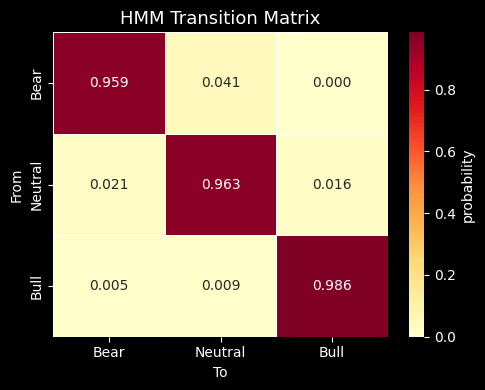

In [84]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    trans, annot=True, fmt='.3f', cmap='YlOrRd',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'probability'}
)
ax.set_title('HMM Transition Matrix', fontsize=13)
ax.set_xlabel('To')
ax.set_ylabel('From')
plt.tight_layout()
plt.show()

## 5. Regime Timeline

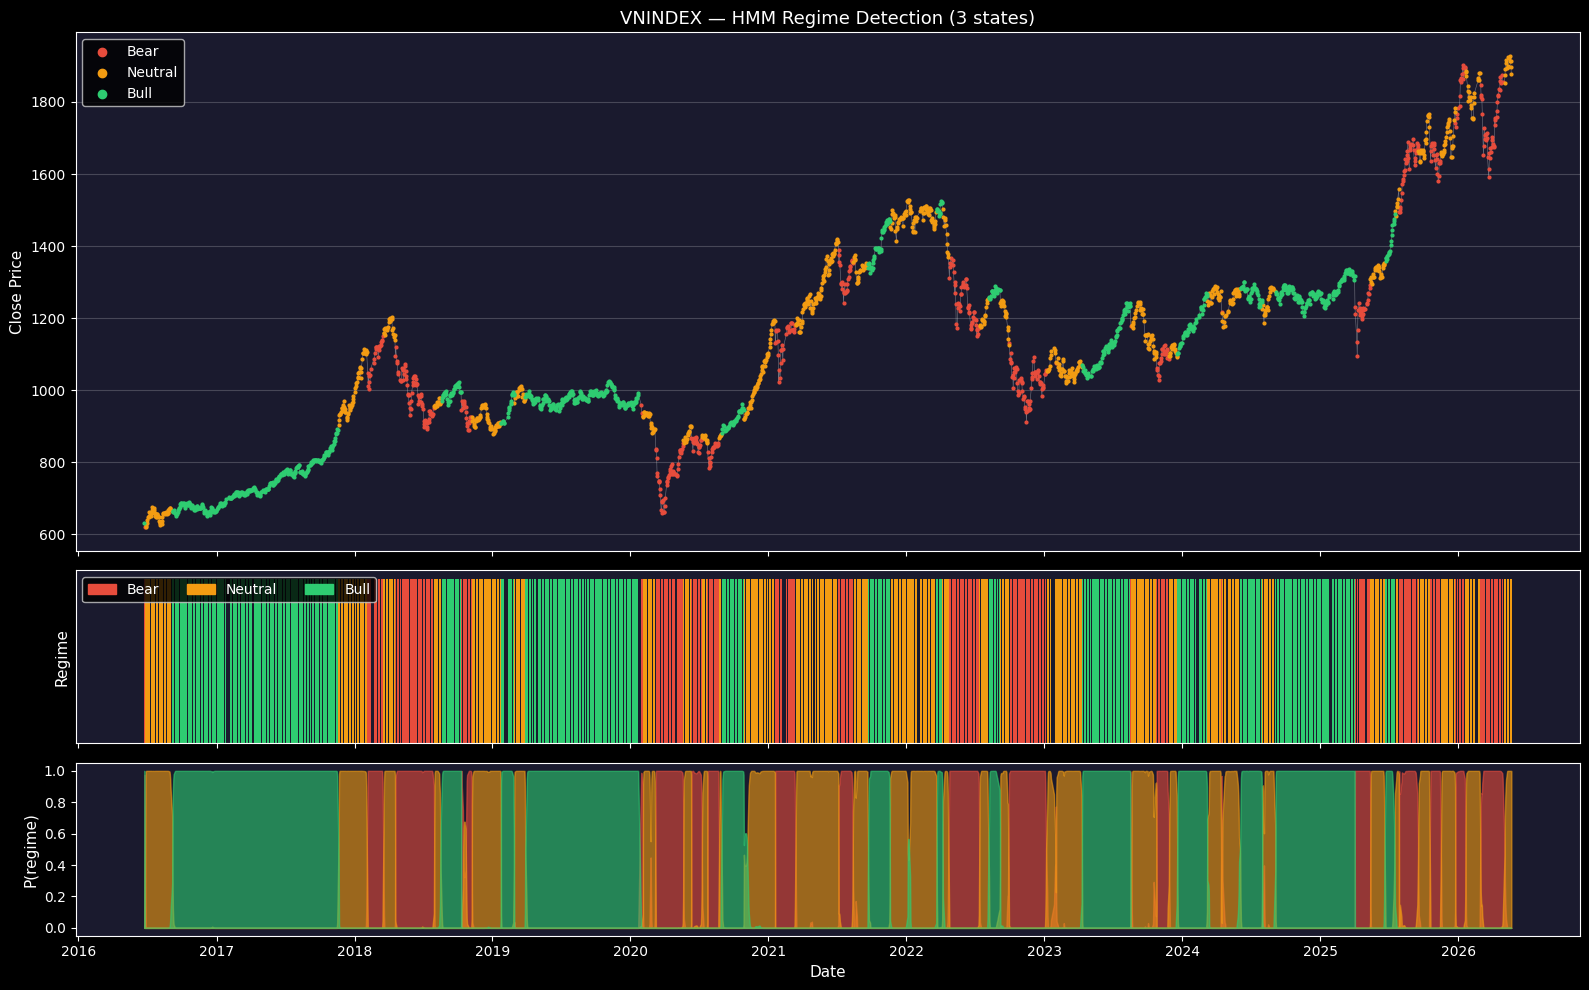

In [85]:
close = df_sym.loc[feat.index, 'close']

fig, axes = plt.subplots(3, 1, figsize=(16, 10),
                         gridspec_kw={'height_ratios': [3, 1, 1]},
                         sharex=True)

# --- panel 1: price coloured by regime ---
ax = axes[0]
ax.set_facecolor('#1a1a2e')
for state in ranked:
    mask = feat['state'] == state
    ax.scatter(
        feat.index[mask], close[mask],
        c=color_map[state], s=4, label=label_map[state], zorder=3
    )
ax.plot(close.index, close.values, color='white', lw=0.4, alpha=0.4, zorder=2)
ax.set_ylabel('Close Price', fontsize=11)
ax.set_title(f'{SYMBOL} — HMM Regime Detection ({N_REGIMES} states)', fontsize=13)
ax.legend(loc='upper left', markerscale=3)
ax.yaxis.grid(True, alpha=0.2)

# --- panel 2: regime bar ---
ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
regime_num = feat['state'].map({s: i for i, s in enumerate(ranked)})
colors_arr = [color_map[s] for s in feat['state']]
ax2.bar(feat.index, np.ones(len(feat)), color=colors_arr, width=1.5, align='center')
ax2.set_yticks([])
ax2.set_ylabel('Regime', fontsize=11)
patches = [mpatches.Patch(color=color_map[s], label=label_map[s]) for s in ranked]
ax2.legend(handles=patches, loc='upper left', ncol=3)

# --- panel 3: state probabilities ---
ax3 = axes[2]
ax3.set_facecolor('#1a1a2e')
for i, s in enumerate(ranked):
    ax3.fill_between(feat.index, state_probs[:, s],
                     alpha=0.6, color=color_map[s], label=label_map[s])
ax3.set_ylabel('P(regime)', fontsize=11)
ax3.set_xlabel('Date', fontsize=11)
ax3.xaxis.set_major_locator(mdates.YearLocator())
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.tight_layout()
plt.show()

## 6. Regime Statistics

In [86]:
stats_rows = []
for s in ranked:
    sub = feat.loc[feat['state'] == s, 'log_ret']
    ann_ret = sub.mean() * 252
    ann_vol = sub.std()  * np.sqrt(252)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    # avg duration via run-length encoding
    changes = (feat['state'] != feat['state'].shift()).cumsum()
    durations = (
        feat[feat['state'] == s]
        .groupby(changes[feat['state'] == s])
        .size()
    )
    stats_rows.append({
        'Regime':         label_map[s],
        'Count':          len(sub),
        'Fraction':       f"{len(sub)/len(feat):.1%}",
        'Ann. Return':    f"{ann_ret:.1%}",
        'Ann. Vol':       f"{ann_vol:.1%}",
        'Sharpe':         f"{sharpe:.2f}",
        'Avg Duration':   f"{durations.mean():.1f} days",
        'Max Duration':   f"{durations.max()} days",
    })

display(pd.DataFrame(stats_rows).set_index('Regime'))

,Count,Fraction,Ann. Return,Ann. Vol,Sharpe,Avg Duration,Max Duration
Regime,,,,,,,
Bear,563,22.7%,-34.3%,31.3%,-1.10,26.8 days,70 days
Neutral,883,35.6%,24.1%,16.0%,1.50,29.4 days,81 days
Bull,1032,41.6%,24.8%,9.8%,2.53,73.7 days,304 days


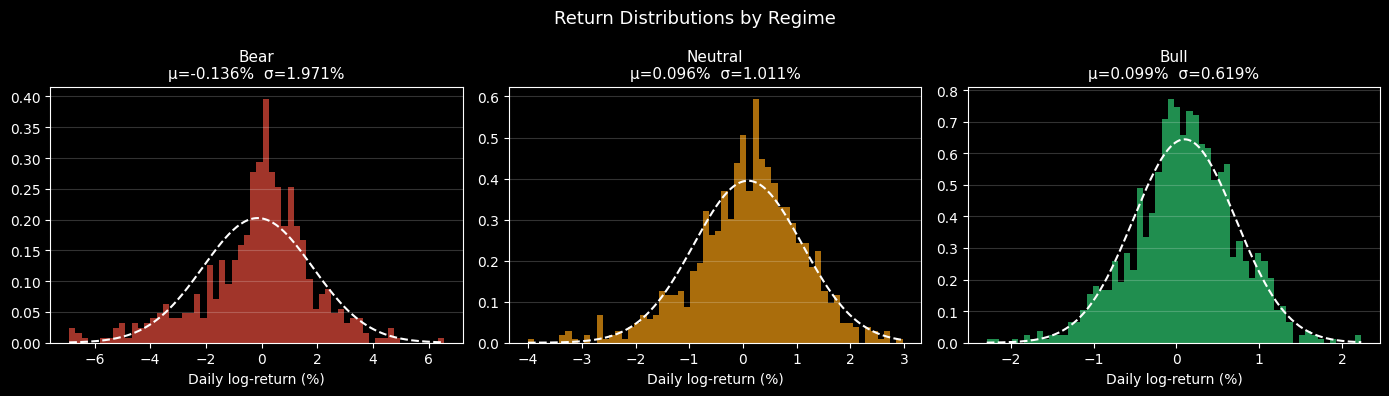

In [87]:
# ── return distributions per regime ──────────────────────────────────────────
fig, axes = plt.subplots(1, N_REGIMES, figsize=(14, 4), sharey=False)

for ax, s in zip(axes, ranked):
    sub = feat.loc[feat['state'] == s, 'log_ret'] * 100
    ax.hist(sub, bins=60, color=color_map[s], alpha=0.7, density=True, edgecolor='none')
    x = np.linspace(sub.min(), sub.max(), 200)
    ax.plot(x, norm.pdf(x, sub.mean(), sub.std()), 'w--', lw=1.5)
    ax.set_title(f"{label_map[s]}\nμ={sub.mean():.3f}%  σ={sub.std():.3f}%", fontsize=11)
    ax.set_xlabel('Daily log-return (%)')
    ax.yaxis.grid(True, alpha=0.2)

fig.suptitle('Return Distributions by Regime', fontsize=13)
fig.tight_layout()
plt.show()

## 7. Model Selection — BIC / AIC across n_components

n=2  ll=-28467372.5  AIC=56934831.0  BIC=56935081.0  conv=True
n=3  ll=-25534875.6  AIC=51069887.3  BIC=51070282.7  conv=True
n=4  ll=-24425161.7  AIC=48850513.5  BIC=48851065.9  conv=True
n=5  ll=-22661943.7  AIC=45324135.3  BIC=45324856.4  conv=True
n=6  ll=-21827856.5  AIC=43656023.0  BIC=43656924.4  conv=True


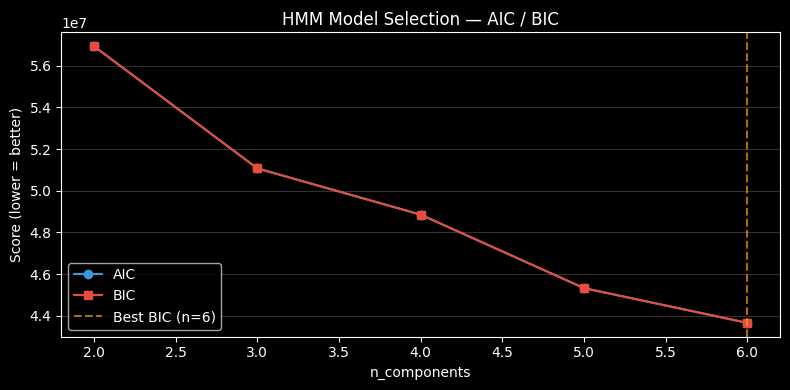

,log-likelihood,AIC,BIC,converged
n,,,,
2,-2.846737e+07,5.693483e+07,5.693508e+07,True
3,-2.553488e+07,5.106989e+07,5.107028e+07,True
4,-2.442516e+07,4.885051e+07,4.885107e+07,True
5,-2.266194e+07,4.532414e+07,4.532486e+07,True
6,-2.182786e+07,4.365602e+07,4.365692e+07,True


In [88]:
results = []
for n in range(2, 7):
    m = GaussianHMM(
        n_components=n, covariance_type='full',
        n_iter=200, random_state=RANDOM_SEED, tol=1e-4
    )
    m.fit(X)
    ll   = m.score(X) * len(X)
    d    = len(FEATURE_COLS)   # observation dimension
    # free params: transmat (n*(n-1)), startprob (n-1), means (n*d), covs (n*d*(d+1)/2)
    k    = n*(n-1) + (n-1) + n*d + n*d*(d+1)//2
    T    = len(X)
    aic  = -2*ll + 2*k
    bic  = -2*ll + k*np.log(T)
    results.append({'n': n, 'log-likelihood': ll, 'AIC': aic, 'BIC': bic,
                    'converged': m.monitor_.converged})
    print(f'n={n}  ll={ll:.1f}  AIC={aic:.1f}  BIC={bic:.1f}  conv={m.monitor_.converged}')

res_df = pd.DataFrame(results).set_index('n')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(res_df.index, res_df['AIC'], 'o-', label='AIC', color='#3498db')
ax.plot(res_df.index, res_df['BIC'], 's-', label='BIC', color='#e74c3c')
best_bic = res_df['BIC'].idxmin()
ax.axvline(best_bic, ls='--', color='#f39c12', alpha=0.7, label=f'Best BIC (n={best_bic})')
ax.set_xlabel('n_components')
ax.set_ylabel('Score (lower = better)')
ax.set_title('HMM Model Selection — AIC / BIC')
ax.legend()
ax.yaxis.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

display(res_df)

## 8. Regime-Conditioned Cumulative Return

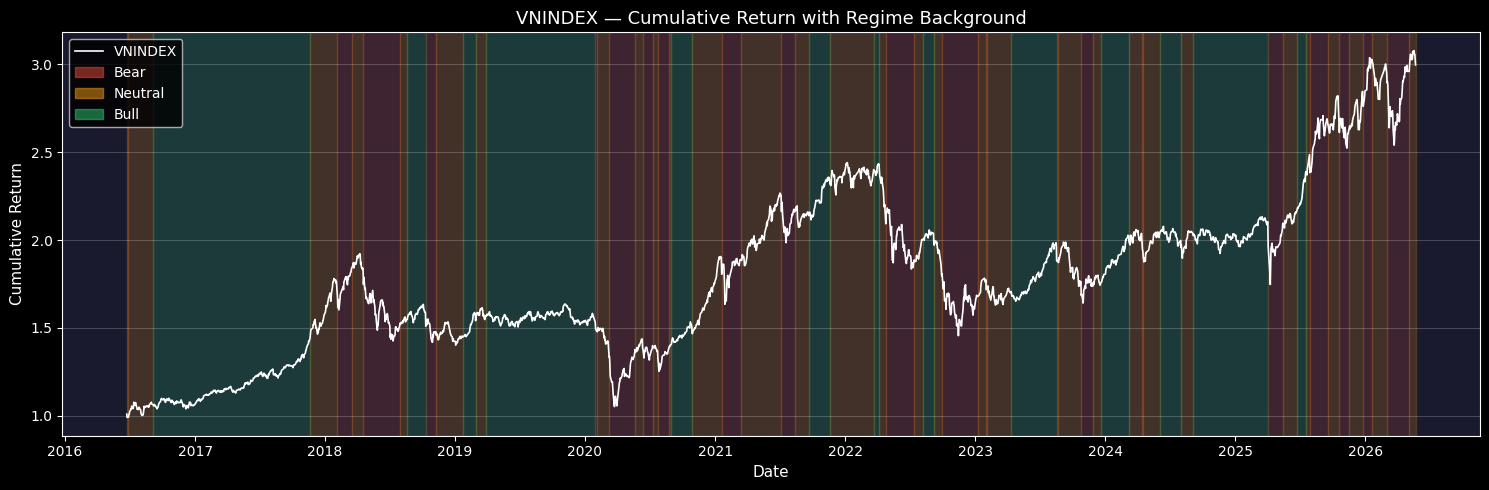

In [89]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_facecolor('#1a1a2e')

cum_total = feat['log_ret'].cumsum().apply(np.exp)
ax.plot(cum_total.index, cum_total.values, color='white', lw=1.2, label=SYMBOL, zorder=5)

# shade background by regime
prev_idx = feat.index[0]
prev_state = feat['state'].iloc[0]
for i in range(1, len(feat)):
    cur_state = feat['state'].iloc[i]
    if cur_state != prev_state or i == len(feat) - 1:
        ax.axvspan(prev_idx, feat.index[i], alpha=0.18,
                   color=color_map[prev_state], zorder=1)
        prev_idx  = feat.index[i]
        prev_state = cur_state

patches = [mpatches.Patch(color=color_map[s], alpha=0.5, label=label_map[s]) for s in ranked]
ax.legend(handles=[ax.lines[0]] + patches, loc='upper left')
ax.set_ylabel('Cumulative Return', fontsize=11)
ax.set_xlabel('Date', fontsize=11)
ax.set_title(f'{SYMBOL} — Cumulative Return with Regime Background', fontsize=13)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.yaxis.grid(True, alpha=0.2)
fig.tight_layout()
plt.show()

---
## 9. KMeans Regime Detection — Feature Engineering

New feature set designed to capture **trend + volatility + momentum**:

| Feature | Description |
|---------|-------------|
| `log_ret` | Daily log-return |
| `yz_vol` | Yang-Zhang volatility (annualised) — uses OHLC, handles overnight gaps |
| `ma_ratio_50` | close / MA50 − 1 (trend position relative to medium-term average) |
| `ma_ratio_200` | close / MA200 − 1 (trend position relative to long-term average) |
| `rsi` | RSI-14 (momentum oscillator) |

Yang-Zhang is preferred over simple rolling-std because it uses open/high/low/close
to get a less biased estimate of true volatility, especially over overnight gaps.

In [90]:
# yang_zhang_vol() defined in §2 — reused here as yz_vol

# ── RSI-14 ───────────────────────────────────────────────────────────────────
def calc_rsi(close, period=14):
    delta = close.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / loss
    return 100 - (100 / (1 + rs))


# ── build KMeans feature matrix ───────────────────────────────────────────────
km_feat = pd.DataFrame(index=df_sym.index)

km_feat['log_ret']      = np.log(df_sym['close'] / df_sym['close'].shift(1))
km_feat['yz_vol']       = yang_zhang_vol(
                              df_sym['open'], df_sym['high'],
                              df_sym['low'],  df_sym['close'], window=20)
km_feat['ma_ratio_50']  = df_sym['close'] / df_sym['close'].rolling(50).mean()  - 1
km_feat['ma_ratio_200'] = df_sym['close'] / df_sym['close'].rolling(200).mean() - 1
km_feat['rsi']          = calc_rsi(df_sym['close'], period=14)

km_feat = km_feat.dropna()
print(f'KMeans feature matrix: {km_feat.shape}  '
      f'| {km_feat.index[0].date()} → {km_feat.index[-1].date()}')
km_feat.describe().round(4)


KMeans feature matrix: (2299, 5)  | 2017-03-10 → 2026-05-22


,log_ret,yz_vol,ma_ratio_50,ma_ratio_200,rsi
count,2299.0000,2299.0000,2299.0000,2299.0000,2299.0000
mean,0.0004,0.1604,0.0110,0.0452,56.2258
std,0.0122,0.0764,0.0534,0.1145,19.1889
min,-0.0691,0.0514,-0.2601,-0.3115,3.1853
25%,-0.0042,0.1016,-0.0147,-0.0256,41.6005
50%,0.0014,0.1461,0.0153,0.0415,56.4092
75%,0.0065,0.1956,0.0432,0.1061,70.8484
max,0.0655,0.5134,0.1500,0.3419,99.6223


## 10. KMeans — Choose k (Elbow + Silhouette)

  k=2  inertia=7947.5  silhouette=0.3196
  k=3  inertia=6601.4  silhouette=0.2256
  k=4  inertia=5748.8  silhouette=0.2385
  k=5  inertia=4957.3  silhouette=0.2334
  k=6  inertia=4610.0  silhouette=0.2199
  k=7  inertia=4308.9  silhouette=0.2155


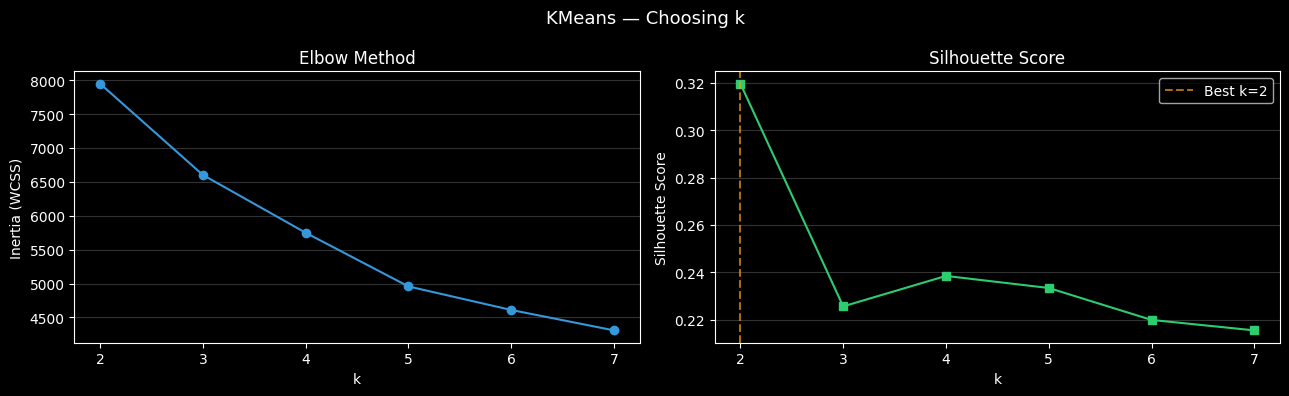


Suggested k by silhouette: 2


In [91]:
from sklearn.cluster import KMeans
from sklearn.metrics  import silhouette_score

KM_FEATURE_COLS = ['log_ret', 'yz_vol', 'ma_ratio_50', 'ma_ratio_200', 'rsi']

km_scaler = StandardScaler()
X_km      = km_scaler.fit_transform(km_feat[KM_FEATURE_COLS].values)

inertias   = []
silhouettes = []
ks = range(2, 8)

for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_SEED)
    labels = km.fit_predict(X_km)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_km, labels, sample_size=2000,
                                        random_state=RANDOM_SEED))
    print(f'  k={k}  inertia={km.inertia_:.1f}  silhouette={silhouettes[-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(ks), inertias, 'o-', color='#3498db')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method'); axes[0].yaxis.grid(True, alpha=0.2)

axes[1].plot(list(ks), silhouettes, 's-', color='#2ecc71')
best_k = list(ks)[int(np.argmax(silhouettes))]
axes[1].axvline(best_k, ls='--', color='#f39c12', alpha=0.7,
                label=f'Best k={best_k}')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score'); axes[1].legend()
axes[1].yaxis.grid(True, alpha=0.2)

fig.suptitle('KMeans — Choosing k', fontsize=13)
fig.tight_layout(); plt.show()
print(f'\nSuggested k by silhouette: {best_k}')


## 11. Fit KMeans (k=3) & Label Regimes

In [92]:
K_REGIMES = 3

km_final = KMeans(n_clusters=K_REGIMES, n_init=30, random_state=RANDOM_SEED)
km_labels = km_final.fit_predict(X_km)

km_feat['km_state'] = km_labels

# Label clusters by mean log-return (same convention as HMM)
km_mean_ret = {
    c: km_feat.loc[km_feat['km_state'] == c, 'log_ret'].mean()
    for c in range(K_REGIMES)
}
km_ranked   = sorted(km_mean_ret, key=km_mean_ret.get)
km_label_map = {km_ranked[0]: 'Bear', km_ranked[1]: 'Neutral', km_ranked[2]: 'Bull'}
km_color_map = {km_ranked[0]: '#e74c3c', km_ranked[1]: '#f39c12', km_ranked[2]: '#2ecc71'}

km_feat['km_regime'] = km_feat['km_state'].map(km_label_map)

for c in km_ranked:
    sub = km_feat[km_feat['km_state'] == c]
    print(f"Cluster {c} → {km_label_map[c]:7s}  "
          f"mean_ret={km_mean_ret[c]*100:.3f}%  "
          f"count={len(sub)}  frac={len(sub)/len(km_feat):.1%}")

# silhouette score of final model
sil = silhouette_score(X_km, km_labels, sample_size=3000, random_state=RANDOM_SEED)
print(f'\nSilhouette score (k=3): {sil:.4f}')


Cluster 0 → Bear     mean_ret=-0.422%  count=397  frac=17.3%
Cluster 2 → Neutral  mean_ret=-0.077%  count=1049  frac=45.6%
Cluster 1 → Bull     mean_ret=0.404%  count=853  frac=37.1%

Silhouette score (k=3): 0.2265


In [93]:
# ── KMeans cluster centroids (feature space) ──────────────────────────────────
centroids_df = pd.DataFrame(
    km_scaler.inverse_transform(km_final.cluster_centers_),
    columns=KM_FEATURE_COLS,
    index=[km_label_map[c] for c in range(K_REGIMES)]
)
print('Cluster centroids (original scale):')
display(centroids_df.T.round(4))


Cluster centroids (original scale):


,Bear,Bull,Neutral
log_ret,-0.0042,0.0040,-0.0008
yz_vol,0.2672,0.1491,0.1291
ma_ratio_50,-0.0701,0.0564,0.0047
ma_ratio_200,-0.0828,0.1321,0.0230
rsi,36.7887,73.2815,49.6905


## 12. KMeans — Timeline & Statistics

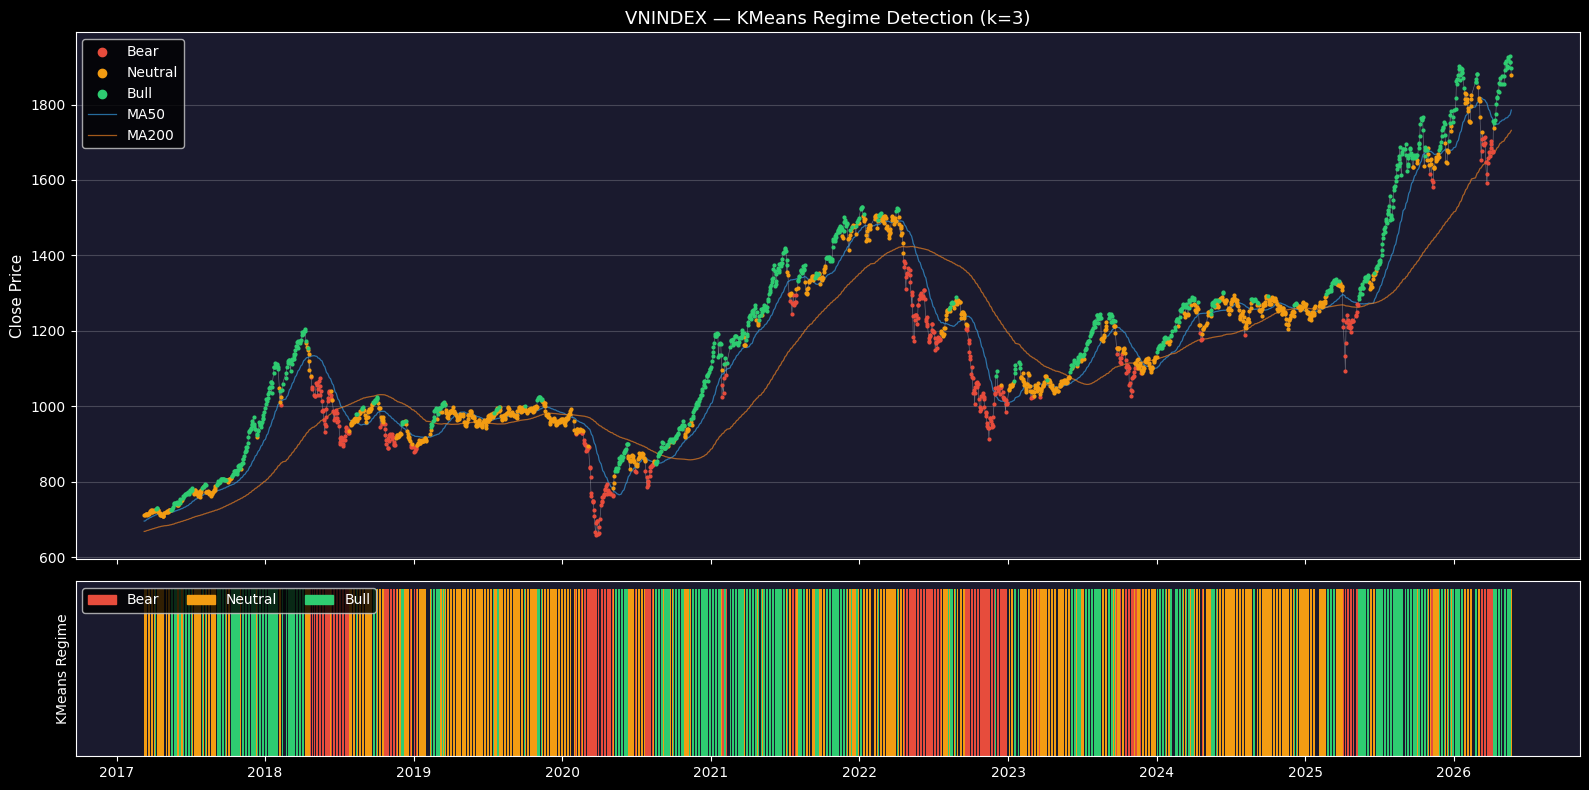

In [94]:
close_km = df_sym.loc[km_feat.index, 'close']

fig, axes = plt.subplots(2, 1, figsize=(16, 8),
                          gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

ax = axes[0]; ax.set_facecolor('#1a1a2e')
for c in km_ranked:
    mask = km_feat['km_state'] == c
    ax.scatter(km_feat.index[mask], close_km[mask],
               c=km_color_map[c], s=4, label=km_label_map[c], zorder=3)
ax.plot(close_km.index, close_km.values, color='white', lw=0.4, alpha=0.4)

# MA lines
ma50  = df_sym['close'].rolling(50).mean().reindex(km_feat.index)
ma200 = df_sym['close'].rolling(200).mean().reindex(km_feat.index)
ax.plot(km_feat.index, ma50,  color='#3498db', lw=0.9, alpha=0.7, label='MA50')
ax.plot(km_feat.index, ma200, color='#e67e22', lw=0.9, alpha=0.7, label='MA200')

ax.set_ylabel('Close Price', fontsize=11)
ax.set_title(f'{SYMBOL} — KMeans Regime Detection (k=3)', fontsize=13)
ax.legend(loc='upper left', markerscale=3); ax.yaxis.grid(True, alpha=0.2)

ax2 = axes[1]; ax2.set_facecolor('#1a1a2e')
colors_km = [km_color_map[s] for s in km_feat['km_state']]
ax2.bar(km_feat.index, np.ones(len(km_feat)), color=colors_km, width=1.5)
ax2.set_yticks([]); ax2.set_ylabel('KMeans Regime')
patches = [mpatches.Patch(color=km_color_map[c], label=km_label_map[c]) for c in km_ranked]
ax2.legend(handles=patches, loc='upper left', ncol=3)
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.tight_layout(); plt.show()


In [95]:
# ── KMeans regime statistics ──────────────────────────────────────────────────
km_stats_rows = []
for c in km_ranked:
    sub = km_feat.loc[km_feat['km_state'] == c, 'log_ret']
    ann_ret = sub.mean() * 252
    ann_vol = sub.std()  * np.sqrt(252)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    changes   = (km_feat['km_state'] != km_feat['km_state'].shift()).cumsum()
    durations = km_feat[km_feat['km_state'] == c].groupby(
                    changes[km_feat['km_state'] == c]).size()
    km_stats_rows.append({
        'Regime':       km_label_map[c],
        'Count':        len(sub),
        'Fraction':     f'{len(sub)/len(km_feat):.1%}',
        'Ann. Return':  f'{ann_ret:.1%}',
        'Ann. Vol':     f'{ann_vol:.1%}',
        'Sharpe':       f'{sharpe:.2f}',
        'Avg Duration': f'{durations.mean():.1f} days',
        'Max Duration': f'{durations.max()} days',
    })

display(pd.DataFrame(km_stats_rows).set_index('Regime'))


,Count,Fraction,Ann. Return,Ann. Vol,Sharpe,Avg Duration,Max Duration
Regime,,,,,,,
Bear,397,17.3%,-106.3%,31.7%,-3.35,8.4 days,63 days
Neutral,1049,45.6%,-19.3%,15.2%,-1.27,7.0 days,80 days
Bull,853,37.1%,101.7%,13.8%,7.36,7.7 days,62 days


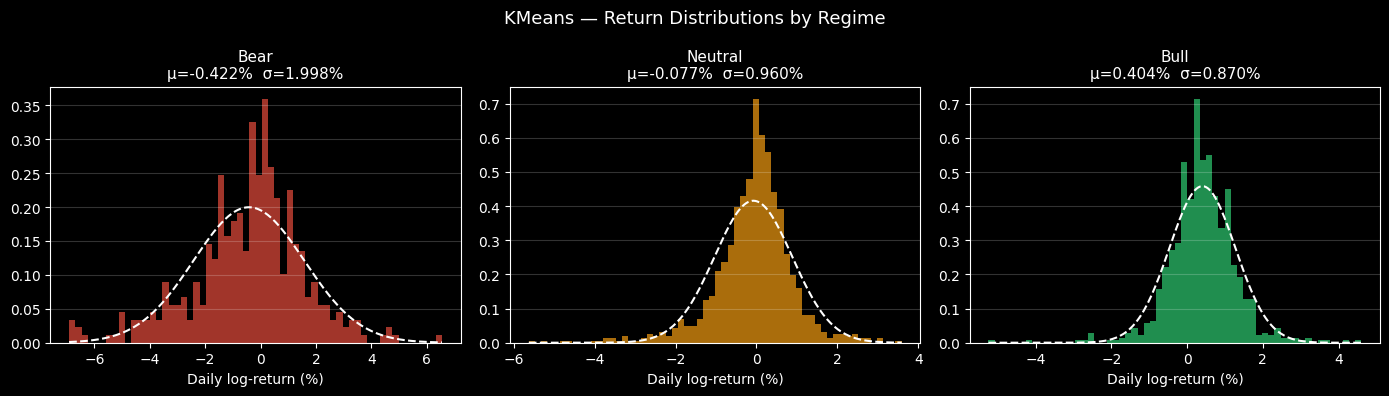

In [96]:
# ── return distributions ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, K_REGIMES, figsize=(14, 4), sharey=False)
for ax, c in zip(axes, km_ranked):
    sub = km_feat.loc[km_feat['km_state'] == c, 'log_ret'] * 100
    ax.hist(sub, bins=60, color=km_color_map[c], alpha=0.7, density=True, edgecolor='none')
    x = np.linspace(sub.min(), sub.max(), 200)
    ax.plot(x, norm.pdf(x, sub.mean(), sub.std()), 'w--', lw=1.5)
    ax.set_title(f"{km_label_map[c]}\nμ={sub.mean():.3f}%  σ={sub.std():.3f}%", fontsize=11)
    ax.set_xlabel('Daily log-return (%)'); ax.yaxis.grid(True, alpha=0.2)
fig.suptitle('KMeans — Return Distributions by Regime', fontsize=13)
fig.tight_layout(); plt.show()


## 13. HMM vs KMeans — Head-to-Head Comparison

We compare both models on the **same date range** using aligned labels.
Since both models label by mean-return rank, Bear/Neutral/Bull are comparable.

Common date range: 2017-03-10 → 2026-05-22
Days: 2299

Overall agreement: 44.8%
Cohen kappa:        0.147  (0=chance, 1=perfect)


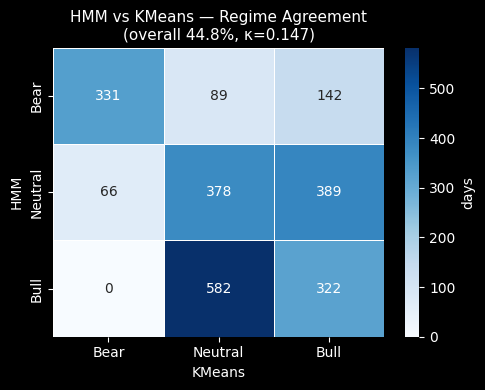

In [97]:
# ── align both regimes on common dates ───────────────────────────────────────
common_idx = feat.index.intersection(km_feat.index)

hmm_regime = feat.loc[common_idx, 'regime']
km_regime  = km_feat.loc[common_idx, 'km_regime']
log_ret_common = feat.loc[common_idx, 'log_ret']

print(f'Common date range: {common_idx[0].date()} → {common_idx[-1].date()}')
print(f'Days: {len(common_idx)}')

# ── regime agreement matrix ───────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, cohen_kappa_score

order = ['Bear', 'Neutral', 'Bull']
agree_mat = pd.crosstab(hmm_regime, km_regime,
                         rownames=['HMM'], colnames=['KMeans'])[order].loc[order]

overall_agree = (hmm_regime == km_regime).mean()
kappa         = cohen_kappa_score(hmm_regime, km_regime)

print(f'\nOverall agreement: {overall_agree:.1%}')
print(f'Cohen kappa:        {kappa:.3f}  (0=chance, 1=perfect)')

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(agree_mat, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'days'})
ax.set_title(f'HMM vs KMeans — Regime Agreement\n'
             f'(overall {overall_agree:.1%}, κ={kappa:.3f})', fontsize=11)
fig.tight_layout(); plt.show()


In [98]:
# ── per-regime stats: HMM vs KMeans side-by-side ────────────────────────────
def regime_stats(regime_series, ret_series, model_name):
    rows = []
    for lbl in ['Bear', 'Neutral', 'Bull']:
        sub = ret_series[regime_series == lbl]
        if len(sub) == 0:
            continue
        ann_ret = sub.mean() * 252
        ann_vol = sub.std()  * np.sqrt(252)
        sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
        # avg duration
        changes   = (regime_series != regime_series.shift()).cumsum()
        durations = regime_series[regime_series == lbl].groupby(
                        changes[regime_series == lbl]).size()
        rows.append({
            'Model':        model_name,
            'Regime':       lbl,
            'Days':         len(sub),
            'Frac':         f'{len(sub)/len(ret_series):.1%}',
            'Ann Ret':      f'{ann_ret:.2%}',
            'Ann Vol':      f'{ann_vol:.2%}',
            'Sharpe':       round(sharpe, 3),
            'Avg Dur (d)':  round(durations.mean(), 1),
            'Max Dur (d)':  durations.max(),
        })
    return pd.DataFrame(rows)

stats_hmm = regime_stats(hmm_regime, log_ret_common, 'HMM')
stats_km  = regime_stats(km_regime,  log_ret_common, 'KMeans')
combined  = pd.concat([stats_hmm, stats_km]).set_index(['Model', 'Regime'])

print('=== Regime Statistics — HMM vs KMeans ===')
display(combined)


=== Regime Statistics — HMM vs KMeans ===


Days   Frac   Ann Ret Ann Vol  Sharpe  Avg Dur (d)  \
Model  Regime                                                        
HMM    Bear      562  24.4%   -33.50%  31.29%  -1.071         28.1   
       Neutral   833  36.2%    23.53%  16.12%   1.459         28.7   
       Bull      904  39.3%    26.02%   9.78%   2.661         69.5   
KMeans Bear      397  17.3%  -106.30%  31.71%  -3.352          8.4   
       Neutral  1049  45.6%   -19.32%  15.24%  -1.268          7.0   
       Bull      853  37.1%   101.71%  13.81%   7.364          7.7   

                Max Dur (d)  
Model  Regime                
HMM    Bear              70  
       Neutral           81  
       Bull             208  
KMeans Bear              63  
       Neutral           80  
       Bull              62

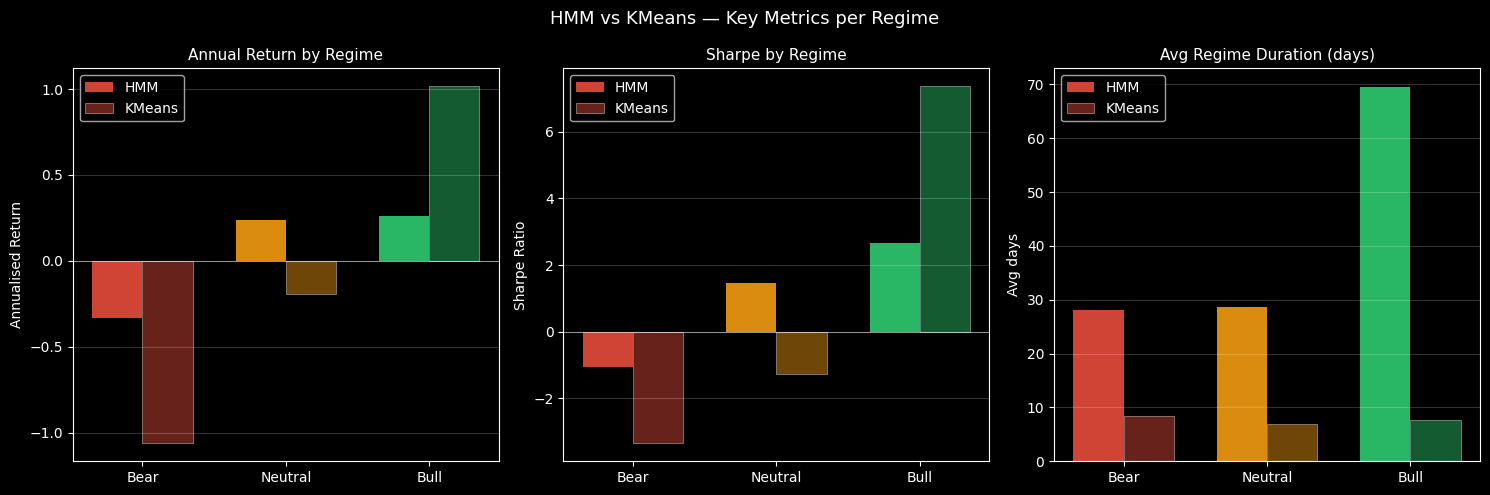

In [99]:
# ── key comparison metrics ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
REGIMES   = ['Bear', 'Neutral', 'Bull']
COLORS    = ['#e74c3c', '#f39c12', '#2ecc71']
x         = np.arange(len(REGIMES))
W_BAR     = 0.35

for ax, metric, ylabel, title in [
    (axes[0], 'Ann Ret',     'Annualised Return', 'Annual Return by Regime'),
    (axes[1], 'Sharpe',      'Sharpe Ratio',      'Sharpe by Regime'),
    (axes[2], 'Avg Dur (d)', 'Avg days',          'Avg Regime Duration (days)'),
]:
    hmm_vals = [stats_hmm.set_index('Regime').loc[r, metric] for r in REGIMES]
    km_vals  = [stats_km.set_index('Regime').loc[r, metric]  for r in REGIMES]

    # convert string percentages to float if needed
    def to_float(v):
        return float(v.strip('%'))/100 if isinstance(v, str) and '%' in v else float(v)

    hmm_vals = [to_float(v) for v in hmm_vals]
    km_vals  = [to_float(v) for v in km_vals]

    bars1 = ax.bar(x - W_BAR/2, hmm_vals, W_BAR,
                   color=[c for c in COLORS], alpha=0.9, label='HMM',    edgecolor='none')
    bars2 = ax.bar(x + W_BAR/2, km_vals,   W_BAR,
                   color=[c for c in COLORS], alpha=0.45, label='KMeans', edgecolor='white',
                   linewidth=0.6)
    ax.set_xticks(x); ax.set_xticklabels(REGIMES)
    ax.set_ylabel(ylabel); ax.set_title(title, fontsize=11)
    ax.axhline(0, color='white', lw=0.7, alpha=0.5)
    ax.yaxis.grid(True, alpha=0.2); ax.legend()

fig.suptitle('HMM vs KMeans — Key Metrics per Regime', fontsize=13)
fig.tight_layout(); plt.show()


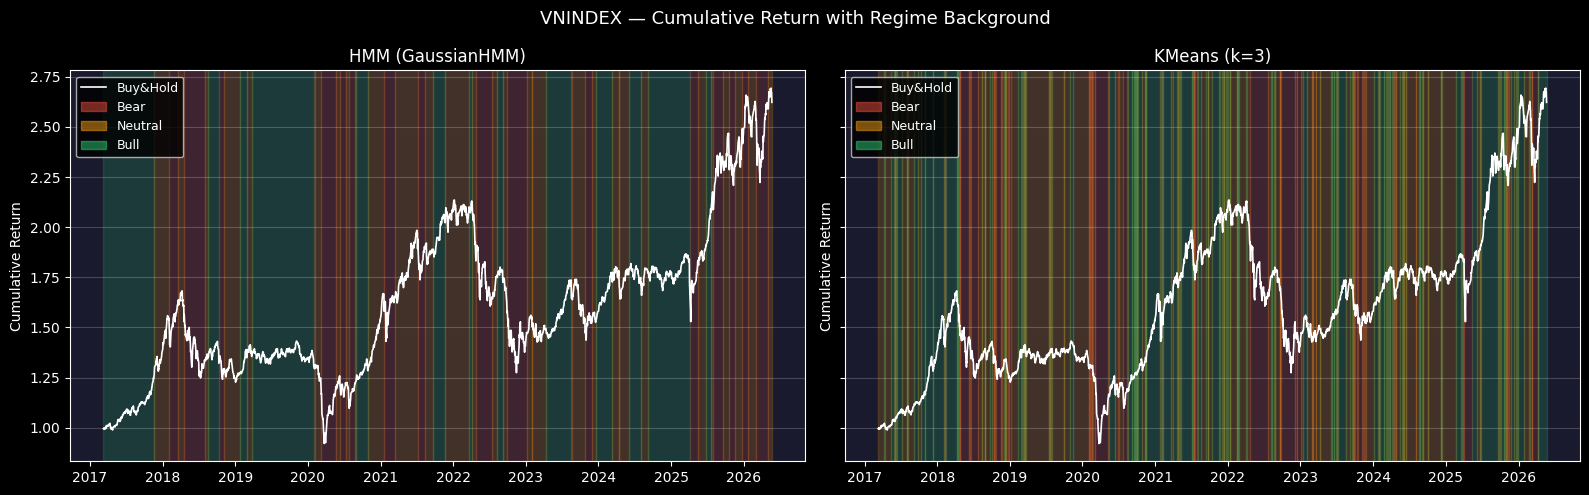

In [100]:
# ── cumulative return by regime: both models ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, (regime_s, model_name) in zip(axes, [
    (hmm_regime, 'HMM (GaussianHMM)'),
    (km_regime,  'KMeans (k=3)'),
]):
    ax.set_facecolor('#1a1a2e')
    cum_total = log_ret_common.cumsum().apply(np.exp)
    ax.plot(cum_total.index, cum_total.values, color='white', lw=1.2, label='Buy&Hold')

    prev_idx   = cum_total.index[0]
    prev_state = regime_s.iloc[0]
    regime_color = {'Bear': '#e74c3c', 'Neutral': '#f39c12', 'Bull': '#2ecc71'}
    for i in range(1, len(cum_total)):
        cur_state = regime_s.iloc[i]
        if cur_state != prev_state or i == len(cum_total) - 1:
            ax.axvspan(prev_idx, cum_total.index[i],
                       alpha=0.18, color=regime_color.get(prev_state, '#555'))
            prev_idx   = cum_total.index[i]
            prev_state = cur_state

    patches = [mpatches.Patch(color=c, alpha=0.5, label=l)
               for l, c in regime_color.items()]
    ax.legend(handles=[ax.lines[0]] + patches, loc='upper left', fontsize=9)
    ax.set_title(model_name, fontsize=12)
    ax.set_ylabel('Cumulative Return'); ax.yaxis.grid(True, alpha=0.2)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle(f'{SYMBOL} — Cumulative Return with Regime Background', fontsize=13)
fig.tight_layout(); plt.show()


In [101]:
# ── regime stability score (avg duration — longer = more stable / less churn) ─
def avg_duration(regime_s):
    changes = (regime_s != regime_s.shift()).cumsum()
    return regime_s.groupby(changes).size().mean()

hmm_stability = avg_duration(hmm_regime)
km_stability  = avg_duration(km_regime)

# ── bull-bear separation (Bear Sharpe vs Bull Sharpe spread) ──────────────────
def bb_spread(stats_df):
    s = stats_df.set_index('Regime')['Sharpe']
    return float(s['Bull']) - float(s['Bear'])

hmm_spread = bb_spread(stats_hmm)
km_spread  = bb_spread(stats_km)

# ── summary scorecard ─────────────────────────────────────────────────────────
scorecard = pd.DataFrame({
    'Metric': [
        'Avg regime duration (days)  ↑ more stable',
        'Bull−Bear Sharpe spread     ↑ better separation',
        'Overall agreement with other model',
        'Cohen κ',
    ],
    'HMM':    [f'{hmm_stability:.1f}', f'{hmm_spread:.3f}',
               f'{overall_agree:.1%}', f'{kappa:.3f}'],
    'KMeans': [f'{km_stability:.1f}',  f'{km_spread:.3f}',
               f'{overall_agree:.1%}', f'{kappa:.3f}'],
}).set_index('Metric')

print('=' * 58)
print('          MODEL COMPARISON SCORECARD')
print('=' * 58)
display(scorecard)
print()

# verdict
winner_stability = 'HMM' if hmm_stability > km_stability else 'KMeans'
winner_separation = 'HMM' if hmm_spread > km_spread else 'KMeans'
print(f'More stable regimes  : {winner_stability}')
print(f'Better Bull/Bear sep : {winner_separation}')
print()
print('Notes:')
print('  HMM    — captures sequential dynamics, smoother transitions')
print('  KMeans — faster, interpretable centroids, no temporal info')


          MODEL COMPARISON SCORECARD


,HMM,KMeans
Metric,,
Avg regime duration (days) ↑ more stable,37.1,7.5
Bull−Bear Sharpe spread ↑ better separation,3.732,10.716
Overall agreement with other model,44.8%,44.8%
Cohen κ,0.147,0.147



More stable regimes  : HMM
Better Bull/Bear sep : KMeans

Notes:
  HMM    — captures sequential dynamics, smoother transitions
  KMeans — faster, interpretable centroids, no temporal info


---
## 14. Regime-Switching Kalman Filter — Vol HMM (2-state)

Same RSKF machinery as **§3b** (run that cell first — defines `regime_switching_kalman`).
Here Layer 1 is a **2-state HMM on YZ vol** (`Low / High`); Layer 2 smooths vol again.

| Regime | Q | R | Effect |
|--------|---|---|--------|
| Low | 6e-4 | 6e-4 | heavy smoothing |
| High | 100e-4 | 100e-4 | fast-tracking |


In [102]:
# ── 14a: Fit 2-state HMM on annualised YZ vol ────────────────────────────────
yz_obs = km_feat['yz_vol'].values.reshape(-1, 1)

vol_hmm = GaussianHMM(
    n_components=2, covariance_type='full',
    n_iter=300, random_state=RANDOM_SEED, tol=1e-5
)
vol_hmm.fit(yz_obs)
print(f'Converged: {vol_hmm.monitor_.converged}  |  log-lik: {vol_hmm.score(yz_obs):.2f}')

vol_states = vol_hmm.predict(yz_obs)
vol_probs  = vol_hmm.predict_proba(yz_obs)          # (T, 2)

# Label states Low < High by mean vol
state_mean_vol = {s: yz_obs[vol_states == s, 0].mean() for s in range(2)}
vol_ranked     = sorted(state_mean_vol, key=state_mean_vol.get)  # [low, high]
vol_labels     = {vol_ranked[0]: 'Low', vol_ranked[1]: 'High'}

# Reorder probability columns to Low / High
vol_probs_ord = vol_probs[:, vol_ranked]            # col 0=Low, col 1=High

km_feat['vol_regime'] = pd.Series(vol_states, index=km_feat.index).map(vol_labels)

RC = ['#1D9E75', '#EF9F27']                         # Low / High colours
VOL_NAMES = ['Low', 'High']

for i, s in enumerate(vol_ranked):
    print(f"  State {s} → {vol_labels[s]:4s}  "
          f"mean YZ vol = {state_mean_vol[s]*100:.1f}%  "
          f"count = {int((vol_states == s).sum())}")

print('\nTransition matrix (Low / High):')
T_ord = vol_hmm.transmat_[np.ix_(vol_ranked, vol_ranked)]
print(pd.DataFrame(T_ord, index=['Low', 'High'],
                   columns=['Low', 'High']).round(3))

Converged: True  |  log-lik: 4135.12
  State 0 → Low   mean YZ vol = 9.9%  count = 1049
  State 1 → High  mean YZ vol = 21.2%  count = 1250

Transition matrix (Low / High):
        Low   High
Low   0.987  0.013
High  0.010  0.990


In [103]:
# ── 14b: Vol-regime RSKF (reuses regime_switching_kalman from §3b) ─────────
if 'regime_switching_kalman' not in dir():
    raise RuntimeError('Run §3b first — defines regime_switching_kalman')

KF_Q = [6e-4, 100e-4]
KF_R = [6e-4, 100e-4]

mu_init = [state_mean_vol[s] for s in vol_ranked]
P_init  = list(KF_Q)

kf = regime_switching_kalman(
    km_feat['yz_vol'].values, vol_probs_ord,
    KF_Q, KF_R, mu_init, P_init,
    index=km_feat.index,
)

tail = kf.tail().copy()
for col in ['kv', 'ku', 'kl']:
    tail[col] = (tail[col] * 100).round(2)
print('Vol-RSKF output (last 5 rows):')
print(tail[['kv', 'kl', 'ku', 'kg', 'reg']])


Vol-RSKF output (last 5 rows):
               kv    kl     ku        kg  reg
date                                         
2026-05-18  18.69  6.90  30.48  0.618034    1
2026-05-19  18.76  6.96  30.55  0.618034    1
2026-05-20  19.79  8.00  31.59  0.618034    1
2026-05-21  20.10  8.31  31.89  0.618034    1
2026-05-22  20.31  8.52  32.10  0.618034    1


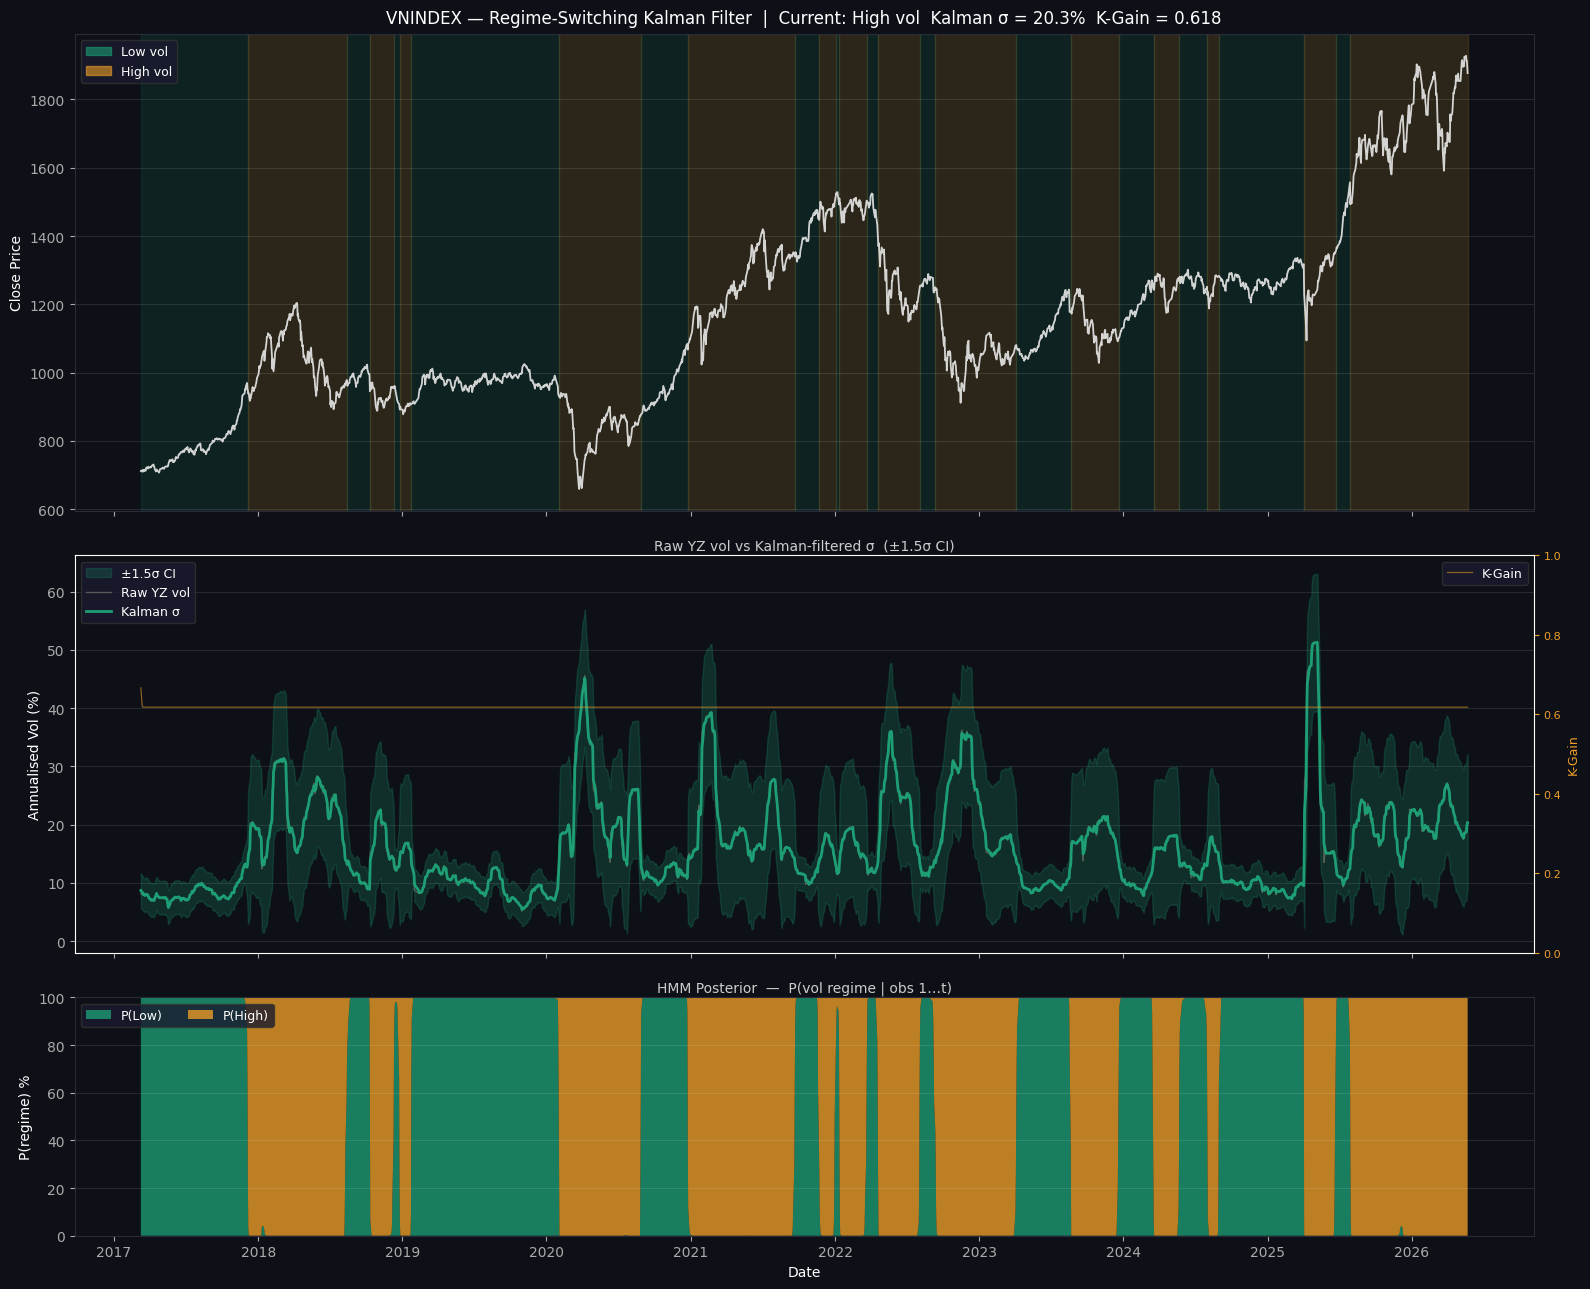

In [104]:
# ── 14c: Three-panel visualisation ───────────────────────────────────────────
VOL_FILL  = ['#1D9E75', '#EF9F27']   # Low / High
VOL_ALPHA = [0.12, 0.14]
VOL_NAMES = ['Low', 'High']

dates   = km_feat.index
close_s = df_sym.loc[dates, 'close']
yz_pct  = km_feat['yz_vol'] * 100
kv_pct  = kf['kv'] * 100
ku_pct  = kf['ku'] * 100
kl_pct  = kf['kl'] * 100

last    = kf.iloc[-1]
cur_reg = int(last['reg'])

fig, axes = plt.subplots(
    3, 1, figsize=(16, 13),
    gridspec_kw={'height_ratios': [3, 2.5, 1.5]},
    sharex=True
)
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#0d1117')
    ax.yaxis.grid(True, alpha=0.15, color='white', lw=0.5)
    ax.spines[:].set_color('#2a2a3a')

# ── Panel 1: Price + vol-regime background ───────────────────────────────────
ax1 = axes[0]
prev_i = dates[0]; prev_r = int(kf['reg'].iloc[0])
for i in range(1, len(dates)):
    cr = int(kf['reg'].iloc[i])
    if cr != prev_r or i == len(dates) - 1:
        ax1.axvspan(prev_i, dates[i],
                    alpha=VOL_ALPHA[prev_r], color=VOL_FILL[prev_r], zorder=1)
        prev_i = dates[i]; prev_r = cr

ax1.plot(dates, close_s.values, color='#e8e8e8', lw=1.3, alpha=0.9, zorder=5)
ax1.set_ylabel('Close Price', fontsize=10)
ax1.set_title(
    f'{SYMBOL} — Regime-Switching Kalman Filter'
    f'  |  Current: {VOL_NAMES[cur_reg]} vol  '
    f'Kalman σ = {last["kv"]*100:.1f}%  K-Gain = {last["kg"]:.3f}',
    fontsize=12, color='white', pad=8
)
patches_p1 = [mpatches.Patch(color=VOL_FILL[i], alpha=0.6, label=f'{VOL_NAMES[i]} vol')
              for i in range(2)]
ax1.legend(handles=patches_p1, loc='upper left', fontsize=9,
           facecolor='#1a1a2e', edgecolor='#333')
ax1.tick_params(colors='#aaa')

# ── Panel 2: Raw YZ vs Kalman + CI + K-Gain ──────────────────────────────────
ax2 = axes[1]
ax2.fill_between(dates, kl_pct, ku_pct,
                 alpha=0.22, color='#1D9E75', label='±1.5σ CI', zorder=2)
ax2.plot(dates, yz_pct, color='#808070', lw=1.0, alpha=0.6, label='Raw YZ vol', zorder=3)
ax2.plot(dates, kv_pct, color='#1D9E75', lw=2.0, label='Kalman σ', zorder=4)
ax2.set_ylabel('Annualised Vol (%)', fontsize=10)
ax2.set_title('Raw YZ vol vs Kalman-filtered σ  (±1.5σ CI)', fontsize=10,
              color='#cccccc', pad=4)
ax2.legend(loc='upper left', fontsize=9, facecolor='#1a1a2e', edgecolor='#333')
ax2.tick_params(colors='#aaa')

ax2r = ax2.twinx()
ax2r.plot(dates, kf['kg'], color='#EF9F27', lw=0.9, alpha=0.55, label='K-Gain')
ax2r.set_ylabel('K-Gain', fontsize=9, color='#EF9F27')
ax2r.tick_params(axis='y', colors='#EF9F27', labelsize=8)
ax2r.set_ylim(0, 1); ax2r.set_facecolor('#0d1117')
ax2r.legend(loc='upper right', fontsize=9, facecolor='#1a1a2e', edgecolor='#333')

# ── Panel 3: HMM posterior probabilities ─────────────────────────────────────
ax3 = axes[2]
pL = vol_probs_ord[:, 0] * 100
pH = vol_probs_ord[:, 1] * 100

ax3.stackplot(dates, pL, pH,
              labels=['P(Low)', 'P(High)'],
              colors=VOL_FILL, alpha=0.78)
ax3.set_ylabel('P(regime) %', fontsize=10)
ax3.set_ylim(0, 100)
ax3.set_xlabel('Date', fontsize=10)
ax3.set_title('HMM Posterior  —  P(vol regime | obs 1…t)', fontsize=10,
              color='#cccccc', pad=4)
ax3.legend(loc='upper left', fontsize=9, ncol=2, facecolor='#1a1a2e', edgecolor='#333')
ax3.xaxis.set_major_locator(mdates.YearLocator())
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax3.tick_params(colors='#aaa')

fig.tight_layout(h_pad=1.5)
plt.show()

In [105]:
# ── 14d: Vol-regime statistics + K-Gain summary ──────────────────────────────
reg_series = pd.Series(kf['reg'].values, index=km_feat.index)

rows = []
for i, name in enumerate(VOL_NAMES):
    mask      = reg_series == i
    sub_r     = km_feat.loc[mask, 'log_ret']
    sub_v     = km_feat.loc[mask, 'yz_vol']
    sub_k     = kf.loc[mask, 'kv']
    sub_g     = kf.loc[mask, 'kg']
    changes   = (reg_series != reg_series.shift()).cumsum()
    durations = reg_series[mask].groupby(changes[mask]).size()
    rows.append({
        'Vol Regime':    name,
        'Days':          int(mask.sum()),
        'Fraction':      f'{mask.mean():.1%}',
        'Mean YZ vol':   f'{sub_v.mean()*100:.1f}%',
        'Mean Kalman σ': f'{sub_k.mean()*100:.1f}%',
        'Mean K-Gain':   f'{sub_g.mean():.3f}',
        'Ann. Return':   f'{sub_r.mean()*252:.1%}',
        'Ann. Vol':      f'{sub_r.std()*np.sqrt(252):.1%}',
        'Avg Duration':  f'{durations.mean():.1f}d',
    })

display(pd.DataFrame(rows).set_index('Vol Regime'))

print(f'\nCurrent snapshot ({km_feat.index[-1].date()}):')
print(f'  Vol regime  : {VOL_NAMES[cur_reg]}')
print(f'  Kalman σ    : {last["kv"]*100:.2f}%')
print(f'  CI          : [{last["kl"]*100:.2f}%, {last["ku"]*100:.2f}%]')
print(f'  K-Gain      : {last["kg"]:.4f}  '
      f'({"data-trusting, fast response" if last["kg"] > 0.5 else "model-trusting, smoothing"})')
print(f'  P(Low/High) : {vol_probs_ord[-1,0]*100:.0f}% / {vol_probs_ord[-1,1]*100:.0f}%')

,Days,Fraction,Mean YZ vol,Mean Kalman σ,Mean K-Gain,Ann. Return,Ann. Vol,Avg Duration
Vol Regime,,,,,,,,
Low,1049,45.6%,9.9%,10.0%,0.618,20.4%,11.6%,74.9d
High,1250,54.4%,21.2%,21.1%,0.618,2.3%,24.0%,89.3d



Current snapshot (2026-05-22):
  Vol regime  : High
  Kalman σ    : 20.31%
  CI          : [8.52%, 32.10%]
  K-Gain      : 0.6180  (data-trusting, fast response)
  P(Low/High) : 0% / 100%


---
## 15. Wasserstein K-Means Regime Detection

**Algorithm** — Treats each rolling window of log-returns as an empirical distribution and clusters distributions by their 1-Wasserstein (Earth Mover's) distance.  
**Non-repainting guarantee** — At bar _t_, the model is fitted on non-overlapping windows from bars 0…t-1 only; bar _t_'s label never changes when future data arrives.

| Parameter | Value | Notes |
|-----------|-------|-------|
| `K_CLUSTERS` | 2 | Bull (low vol) / Bear (high vol) |
| `WINDOW_LENGTH` | 10 | Returns per distribution |
| `MIN_TRAINING_WINDOWS` | 20 | Warm-up before classification begins |
| `REFIT_FREQUENCY` | 10 | Re-train every N bars |


In [106]:
from typing import List
from scipy.stats import wasserstein_distance as scipy_wd

# ── Wasserstein K-Means ───────────────────────────────────────────────────────
class WassersteinKMeans:
    def __init__(self, n_clusters=2, max_iter=100, tol=1e-4, random_state=42):
        self.n_clusters    = n_clusters
        self.max_iter      = max_iter
        self.tol           = tol
        self.random_state  = random_state
        self.centroids_    = None

    @staticmethod
    def _wdist(a: np.ndarray, b: np.ndarray) -> float:
        return scipy_wd(a, b)

    @staticmethod
    def _barycenter(dists: List[np.ndarray]) -> np.ndarray:
        return np.median(np.stack([np.sort(d) for d in dists], axis=0), axis=0)

    def fit(self, distributions: List[np.ndarray]):
        rng  = np.random.default_rng(self.random_state)
        idx  = rng.choice(len(distributions), self.n_clusters, replace=False)
        cents = [distributions[i].copy() for i in idx]

        for _ in range(self.max_iter):
            labels = np.array([np.argmin([self._wdist(d, c) for c in cents])
                               for d in distributions])
            new_cents = []
            for k in range(self.n_clusters):
                members = [distributions[i] for i in range(len(distributions)) if labels[i] == k]
                new_cents.append(
                    self._barycenter(members) if members
                    else distributions[rng.integers(len(distributions))].copy()
                )
            shift = sum(self._wdist(o, n) for o, n in zip(cents, new_cents))
            cents = new_cents
            if shift < self.tol:
                break

        # Final labels
        self.centroids_ = cents
        labels = np.array([np.argmin([self._wdist(d, c) for c in cents])
                           for d in distributions])

        # Canonical ordering: cluster 0 = low variance (bull)
        cvars = [np.var(c) for c in cents]
        if cvars[1] < cvars[0]:               # swap so 0=low-var
            self.centroids_ = cents[::-1]
            labels           = 1 - labels
        return labels

    def predict(self, dist: np.ndarray) -> int:
        return int(np.argmin([self._wdist(dist, c) for c in self.centroids_]))


# ── Non-repainting regime classification ─────────────────────────────────────
def non_overlapping_windows(arr: np.ndarray, w: int) -> List[np.ndarray]:
    return [arr[i:i+w] for i in range(0, len(arr)-w+1, w) if len(arr[i:i+w]) == w]


def classify_wasserstein(returns: pd.Series,
                          window_length: int       = 10,
                          min_train_windows: int   = 20,
                          refit_every: int         = 10,
                          n_clusters: int          = 2) -> pd.Series:
    """
    Non-repainting Wasserstein K-Means regime labelling.
    Bar t uses only data from bars 0..t-1 for training.
    """
    arr    = returns.values
    n      = len(arr)
    labels = np.full(n, -1, dtype=int)
    warmup = window_length + min_train_windows * window_length

    model, last_fit = None, -1

    for t in range(warmup, n):
        needs_fit = (model is None
                     or refit_every == 0
                     or (t - last_fit) >= refit_every)
        if needs_fit:
            windows = non_overlapping_windows(arr[:t], window_length)  # only history
            if len(windows) < n_clusters:
                labels[t] = 0; continue
            try:
                model = WassersteinKMeans(n_clusters=n_clusters)
                model.fit(windows)
                last_fit = t
            except Exception:
                labels[t] = labels[t-1] if t > 0 else 0; continue

        win = arr[max(0, t - window_length + 1): t + 1]
        if len(win) < window_length:
            win = np.concatenate([np.zeros(window_length - len(win)), win])
        try:
            labels[t] = model.predict(win)
        except Exception:
            labels[t] = labels[t-1] if t > 0 else 0

    labels[labels == -1] = 0
    return pd.Series(labels, index=returns.index, dtype=int)


print('WassersteinKMeans implementation ready.')


WassersteinKMeans implementation ready.


In [107]:
# ── Parameters ───────────────────────────────────────────────────────────────
WK_WINDOW       = 10   # bars per distribution window
WK_MIN_WINDOWS  = 20   # warm-up: min historical windows before first label
WK_REFIT        = 10   # refit model every N bars  (0 = every bar, slower)
WK_K            = 2    # clusters: 0=bull/low-vol, 1=bear/high-vol

log_ret_wk = np.log(df_sym['close'] / df_sym['close'].shift(1)).dropna()

print(f'Running Wasserstein K-Means on {len(log_ret_wk)} bars ...')
print(f'  window={WK_WINDOW}, min_windows={WK_MIN_WINDOWS}, refit_every={WK_REFIT}')
print(f'  warm-up bars needed: {WK_WINDOW + WK_MIN_WINDOWS * WK_WINDOW}')

wk_labels = classify_wasserstein(
    log_ret_wk,
    window_length     = WK_WINDOW,
    min_train_windows = WK_MIN_WINDOWS,
    refit_every       = WK_REFIT,
    n_clusters        = WK_K,
)

# Attach to df_sym
df_sym['wk_regime'] = wk_labels.reindex(df_sym.index).ffill().fillna(0).astype(int)

# ── Summary statistics ────────────────────────────────────────────────────────
print('\nRegime summary:')
for k, name in [(0, 'Bull / low-vol'), (1, 'Bear / high-vol')]:
    sub = log_ret_wk[wk_labels == k]
    pct = 100 * len(sub) / len(wk_labels)
    print(f'  Cluster {k} ({name:16s}): {len(sub):4d} bars ({pct:.1f}%)'
          f'  mean={sub.mean():.5f}  std={sub.std():.5f}')
print(f'  Regime changes: {int((wk_labels.diff() != 0).sum())}')


Running Wasserstein K-Means on 2497 bars ...
  window=10, min_windows=20, refit_every=10
  warm-up bars needed: 210

Regime summary:
  Cluster 0 (Bull / low-vol  ): 1659 bars (66.4%)  mean=0.00158  std=0.00789
  Cluster 1 (Bear / high-vol ):  838 bars (33.6%)  mean=-0.00178  std=0.01698
  Regime changes: 195


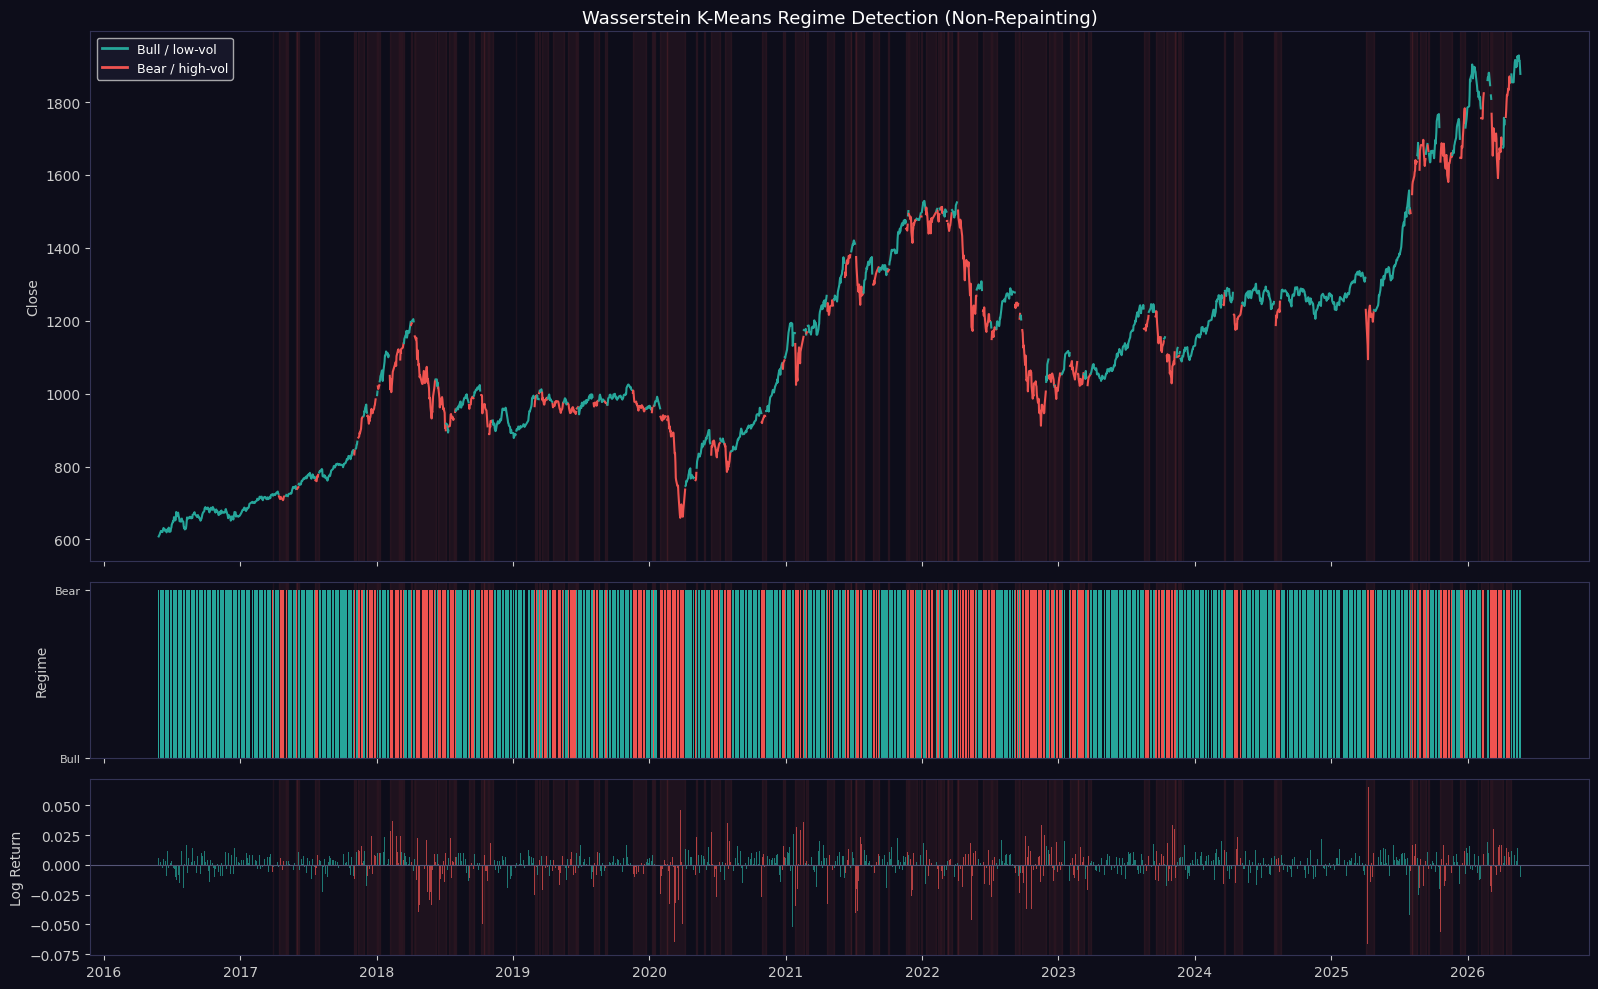

In [108]:
close_wk = df_sym['close'].reindex(wk_labels.index)

fig, axes = plt.subplots(3, 1, figsize=(16, 10),
                          gridspec_kw={'height_ratios': [3, 1, 1]}, sharex=True)
fig.patch.set_facecolor('#0d0d1a')
for ax in axes:
    ax.set_facecolor('#0d0d1a')
    ax.tick_params(colors='#cccccc')
    for sp in ax.spines.values():
        sp.set_edgecolor('#333355')

BULL_COL = '#26a69a'   # teal
BEAR_COL = '#ef5350'   # red
REG_COLS  = {0: BULL_COL, 1: BEAR_COL}
REG_NAMES = {0: 'Bull / low-vol', 1: 'Bear / high-vol'}

# ── Panel 1: price coloured by regime ────────────────────────────────────────
ax = axes[0]
prev_r, seg_start = wk_labels.iloc[0], 0
for i in range(1, len(wk_labels) + 1):
    r = wk_labels.iloc[i] if i < len(wk_labels) else -1
    if r != prev_r or i == len(wk_labels):
        seg_idx = close_wk.index[seg_start: i]
        ax.plot(seg_idx, close_wk.iloc[seg_start: i],
                color=REG_COLS[prev_r], lw=1.5,
                label=REG_NAMES[prev_r] if seg_start == 0 or prev_r not in [wk_labels.iloc[j] for j in range(seg_start)] else '_')
        seg_start, prev_r = i, r

# background shading
bear_mask = wk_labels == 1
in_bear = False
for i, (idx, is_bear) in enumerate(bear_mask.items()):
    if is_bear and not in_bear:
        b_start = idx; in_bear = True
    elif not is_bear and in_bear:
        axes[0].axvspan(b_start, idx, color=BEAR_COL, alpha=0.08)
        axes[1].axvspan(b_start, idx, color=BEAR_COL, alpha=0.08)
        axes[2].axvspan(b_start, idx, color=BEAR_COL, alpha=0.08)
        in_bear = False

ax.set_ylabel('Close', color='#cccccc')
ax.set_title('Wasserstein K-Means Regime Detection (Non-Repainting)',
             color='white', fontsize=13)
handles = [plt.Line2D([0],[0], color=c, lw=2, label=n)
           for k,(c,n) in enumerate(zip([BULL_COL, BEAR_COL],
                                        ['Bull / low-vol', 'Bear / high-vol']))]
ax.legend(handles=handles, facecolor='#1a1a2e', labelcolor='white', fontsize=9)

# ── Panel 2: regime label bar ─────────────────────────────────────────────────
ax = axes[1]
colors_bar = [REG_COLS[r] for r in wk_labels]
ax.bar(wk_labels.index, np.ones(len(wk_labels)), color=colors_bar, width=1.5)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Bull', 'Bear'], color='#cccccc', fontsize=8)
ax.set_ylabel('Regime', color='#cccccc')

# ── Panel 3: log-returns coloured by regime ────────────────────────────────────
ax = axes[2]
ret_colors = [REG_COLS[r] for r in wk_labels]
ax.bar(log_ret_wk.index, log_ret_wk, color=ret_colors, width=1, alpha=0.7)
ax.axhline(0, color='#555577', lw=0.8)
ax.set_ylabel('Log Return', color='#cccccc')

plt.tight_layout()
plt.show()


       Regime  Count   Pct Ann Ret Ann Vol Sharpe Best day Worst day  Skew
 Bull/low-vol   1659 66.4%  39.82%  12.53%   3.18    4.60%    -5.25% -0.38
Bear/high-vol    838 33.6% -44.75%  26.96%  -1.66    6.55%    -6.91% -0.65


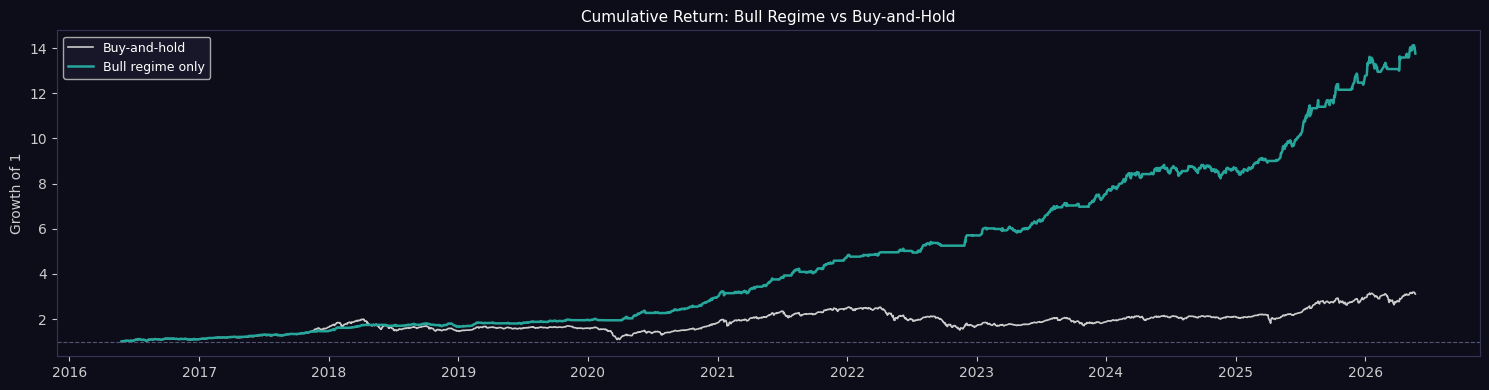

In [109]:
# ── Per-regime statistics ────────────────────────────────────────────────────
wk_feat = pd.DataFrame({'log_ret': log_ret_wk, 'regime': wk_labels})

wk_rows = []
for k, name in [(0, 'Bull/low-vol'), (1, 'Bear/high-vol')]:
    sub = wk_feat[wk_feat['regime'] == k]['log_ret']
    ann = sub.mean() * 252
    vol = sub.std()  * np.sqrt(252)
    sharpe = ann / vol if vol > 0 else np.nan
    wk_rows.append({
        'Regime': name,
        'Count':  len(sub),
        'Pct':    f'{100*len(sub)/len(wk_feat):.1f}%',
        'Ann Ret':    f'{ann:.2%}',
        'Ann Vol':    f'{vol:.2%}',
        'Sharpe':     f'{sharpe:.2f}',
        'Best day':   f'{sub.max():.2%}',
        'Worst day':  f'{sub.min():.2%}',
        'Skew':       f'{sub.skew():.2f}',
    })
wk_stats_df = pd.DataFrame(wk_rows)
print(wk_stats_df.to_string(index=False))

# ── Cumulative return: bull-only vs buy-and-hold ──────────────────────────────
fig, ax = plt.subplots(figsize=(15, 4))
ax.set_facecolor('#0d0d1a')
fig.patch.set_facecolor('#0d0d1a')
ax.tick_params(colors='#cccccc')
for sp in ax.spines.values(): sp.set_edgecolor('#333355')

cum_bnh   = wk_feat['log_ret'].cumsum().apply(np.exp)
cum_bull  = wk_feat.loc[wk_feat['regime']==0, 'log_ret'].reindex(wk_feat.index, fill_value=0)
cum_bull  = cum_bull.cumsum().apply(np.exp)

ax.plot(cum_bnh.index,  cum_bnh,  color='#cccccc', lw=1.2, label='Buy-and-hold')
ax.plot(cum_bull.index, cum_bull, color=BULL_COL,  lw=1.8, label='Bull regime only')
ax.axhline(1, color='#555577', lw=0.8, linestyle='--')
ax.set_title('Cumulative Return: Bull Regime vs Buy-and-Hold',
             color='white', fontsize=11)
ax.set_ylabel('Growth of 1', color='#cccccc')
ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
plt.tight_layout()
plt.show()


In [110]:
# ── Non-repainting verification ──────────────────────────────────────────────
# Split at 80%, compute labels twice, compare the overlapping period.
split = int(len(log_ret_wk) * 0.8)
warmup = WK_WINDOW + WK_MIN_WINDOWS * WK_WINDOW

print('Pass 1: first 80% of bars ...')
labels_p1 = classify_wasserstein(log_ret_wk.iloc[:split],
                                  WK_WINDOW, WK_MIN_WINDOWS, WK_REFIT, WK_K)
print('Pass 2: all bars ...')
labels_p2 = classify_wasserstein(log_ret_wk,
                                  WK_WINDOW, WK_MIN_WINDOWS, WK_REFIT, WK_K)

compare_start = warmup
l1 = labels_p1.iloc[compare_start:].values
l2 = labels_p2.iloc[compare_start:split].values
changed = int(np.sum(l1 != l2))

print(f'\nBars compared : {len(l1)}')
print(f'Labels changed: {changed}')
print(f'Repaint pct   : {100*changed/len(l1):.2f}%')
if changed == 0:
    print('PASS — zero repainting detected.')
else:
    print(f'FAIL — {changed} labels changed when future data was added.')
    print('(Some change is expected if refit_every > 0 — the model seen more training windows)')


Pass 1: first 80% of bars ...
Pass 2: all bars ...

Bars compared : 1787
Labels changed: 0
Repaint pct   : 0.00%
PASS — zero repainting detected.


---
## 16. Four-Model Comparison

Side-by-side comparison of all regime detection approaches on the same date range:

| # | Method | States | Input |
|---|--------|--------|-------|
| §3  | **Gaussian HMM** | Bear / Neutral / Bull | log-ret, vol, YZ-vol, momentum, vol-ratio |
| §11 | **KMeans** | Bear / Neutral / Bull | same feature set |
| §14 | **Vol-HMM RSKF** | Low-vol / High-vol | YZ-vol only |
| §15 | **Wasserstein K-Means** | Bull / Bear | log-return distributions |


In [111]:
from sklearn.metrics import cohen_kappa_score

# ── Build unified regime frame on common dates ───────────────────────────────
# Each method uses its own canonical 'bullish' label:
#   HMM      : regime == 'Bull'
#   KMeans   : km_regime == 'Bull'
#   Vol-RSKF : vol_regime == 'Low'  (low vol = typically expansionary)
#   WK       : wk_labels == 0       (cluster 0 = low variance)

s_hmm = feat['regime']                        # 'Bear'/'Neutral'/'Bull'
s_km  = km_feat['km_regime']                  # 'Bear'/'Neutral'/'Bull'
s_vol = km_feat['vol_regime']                 # 'Low'/'High'
s_wk  = wk_labels.rename('wk_regime')        # 0/1

common = (s_hmm.index
          .intersection(s_km.index)
          .intersection(s_vol.index)
          .intersection(s_wk.index))
print(f'Common date range: {common[0].date()} -> {common[-1].date()}  ({len(common)} bars)')

cmp = pd.DataFrame({
    'log_ret': feat.loc[common, 'log_ret'],
    'close':   df_sym.loc[common, 'close'],
    'HMM':     s_hmm.loc[common],
    'KMeans':  s_km.loc[common],
    'VolRSKF': s_vol.loc[common],
    'WK':      s_wk.loc[common].map({0: 'Bull', 1: 'Bear'}),
})

# Unified binary bull flag for each model
cmp['bull_HMM']     = (cmp['HMM']     == 'Bull').astype(int)
cmp['bull_KMeans']  = (cmp['KMeans']  == 'Bull').astype(int)
cmp['bull_VolRSKF'] = (cmp['VolRSKF'] == 'Low').astype(int)
cmp['bull_WK']      = (cmp['WK']      == 'Bull').astype(int)

MODELS = [
    ('HMM',       'HMM',     'bull_HMM',     '#7e57c2'),
    ('KMeans',    'KMeans',  'bull_KMeans',  '#26a69a'),
    ('Vol-RSKF',  'VolRSKF', 'bull_VolRSKF', '#ef6c00'),
    ('WK',        'WK',      'bull_WK',      '#42a5f5'),
]
print('OK — alignment done')
cmp[['HMM','KMeans','VolRSKF','WK']].tail(5)


TypeError: unsupported operand type(s) for &: 'DatetimeArray' and 'DatetimeArray'

In [ ]:
def _regime_stats(cmp_df, regime_col, bull_flag_col, model_name):
    ret = cmp_df['log_ret']
    rows = []
    regimes = cmp_df[regime_col].unique()
    for r in sorted(regimes):
        mask = cmp_df[regime_col] == r
        sub  = ret[mask]
        if len(sub) == 0:
            continue
        ann_ret = sub.mean() * 252
        ann_vol = sub.std()  * np.sqrt(252)
        changes = mask.astype(int).diff().abs()
        n_spells = int(changes.sum() // 2) + 1
        avg_dur = len(sub) / max(n_spells, 1)
        rows.append({
            'Model':     model_name,
            'Regime':    str(r),
            'Days':      len(sub),
            'Pct':       f'{100*len(sub)/len(cmp_df):.1f}%',
            'Ann Ret':   f'{ann_ret:.2%}',
            'Ann Vol':   f'{ann_vol:.2%}',
            'Sharpe':    f'{ann_ret/ann_vol:.2f}' if ann_vol > 0 else 'N/A',
            'Avg Dur':   f'{avg_dur:.1f}d',
            'N Spells':  n_spells,
        })
    return rows


all_rows = []
for label, reg_col, bull_col, _ in MODELS:
    all_rows.extend(_regime_stats(cmp, reg_col, bull_col, label))

stats_df = pd.DataFrame(all_rows)
print(stats_df.to_string(index=False))


In [ ]:
# ── 4-panel regime timeline: one strip per model ─────────────────────────────
STRIP_COLORS = {
    'Bull':    '#26a69a',
    'Neutral': '#f39c12',
    'Bear':    '#ef5350',
    'Low':     '#26a69a',
    'High':    '#ef5350',
}

fig, axes = plt.subplots(5, 1, figsize=(17, 11),
                          gridspec_kw={'height_ratios': [3, 1, 1, 1, 1]},
                          sharex=True)
fig.patch.set_facecolor('#0d0d1a')
for ax in axes:
    ax.set_facecolor('#0d0d1a')
    ax.tick_params(colors='#cccccc')
    for sp in ax.spines.values(): sp.set_edgecolor('#333355')

# Panel 0: price
axes[0].plot(cmp.index, cmp['close'], color='#cccccc', lw=1)
axes[0].set_ylabel('Close', color='#cccccc')
axes[0].set_title('Regime Timeline — All Four Models', color='white', fontsize=13)

# Panels 1-4: regime strips
strip_info = [
    ('HMM',      'HMM',     axes[1]),
    ('KMeans',   'KMeans',  axes[2]),
    ('Vol-RSKF', 'VolRSKF', axes[3]),
    ('WK',       'WK',      axes[4]),
]
for title, col, ax in strip_info:
    series = cmp[col].astype(str)
    colors = [STRIP_COLORS.get(v, '#888888') for v in series]
    ax.bar(cmp.index, np.ones(len(cmp)), color=colors, width=1.5)
    ax.set_yticks([])
    ax.set_ylabel(title, color='#cccccc', fontsize=9, rotation=0,
                  labelpad=55, va='center')
    # mini legend
    unique_vals = series.unique()
    handles = [plt.Rectangle((0,0),1,1, color=STRIP_COLORS.get(v,'#888'))
               for v in sorted(unique_vals)]
    ax.legend(handles, sorted(unique_vals), loc='upper right',
              fontsize=7, ncol=len(unique_vals),
              facecolor='#1a1a2e', labelcolor='white', framealpha=0.7)

plt.tight_layout()
plt.show()


In [ ]:
# ── Cumulative return: bull-regime-only vs B&H ───────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.set_facecolor('#0d0d1a')
fig.patch.set_facecolor('#0d0d1a')
ax.tick_params(colors='#cccccc')
for sp in ax.spines.values(): sp.set_edgecolor('#333355')

# Buy-and-hold
bnh = cmp['log_ret'].cumsum().apply(np.exp)
ax.plot(bnh.index, bnh, color='#888888', lw=1.2, linestyle='--', label='Buy-and-Hold')

for label, _, bull_col, color in MODELS:
    bull_only = (cmp['log_ret'] * cmp[bull_col]).cumsum().apply(np.exp)
    final_ret = float(bull_only.iloc[-1] - 1)
    ax.plot(bull_only.index, bull_only, color=color, lw=1.8,
            label=f'{label} bull-only ({final_ret:+.1%})')

ax.axhline(1, color='#444466', lw=0.8, linestyle=':')
ax.set_title('Cumulative Return: Bull Regime Only — Model Comparison',
             color='white', fontsize=12)
ax.set_ylabel('Growth of 1', color='#cccccc')
ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
plt.tight_layout()
plt.show()


In [ ]:
# ── Bull/Bear pairwise agreement (Cohen's κ) ────────────────────────────────
bull_cols = [c for _, _, c, _ in MODELS]
model_names = [l for l, _, _, _ in MODELS]

kappa_mat = pd.DataFrame(np.nan, index=model_names, columns=model_names)
agree_mat = pd.DataFrame(np.nan, index=model_names, columns=model_names)
for i, (n1, b1) in enumerate(zip(model_names, bull_cols)):
    for j, (n2, b2) in enumerate(zip(model_names, bull_cols)):
        kappa_mat.loc[n1, n2] = cohen_kappa_score(cmp[b1], cmp[b2])
        agree_mat.loc[n1, n2] = (cmp[b1] == cmp[b2]).mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('#0d0d1a')
for ax in axes:
    ax.set_facecolor('#0d0d1a')
    ax.tick_params(colors='#cccccc')

sns.heatmap(agree_mat.astype(float), annot=True, fmt='.2f',
            cmap='YlGn', vmin=0, vmax=1, ax=axes[0],
            linewidths=0.5, cbar_kws={'label': 'agreement %'})
axes[0].set_title('Pairwise Bull/Bear Agreement', color='white')
axes[0].tick_params(labelcolor='#cccccc')

sns.heatmap(kappa_mat.astype(float), annot=True, fmt='.2f',
            cmap='PuBu',  vmin=-0.1, vmax=1, ax=axes[1],
            linewidths=0.5, cbar_kws={'label': "Cohen's κ"})
axes[1].set_title("Cohen's κ (chance-corrected)", color='white')
axes[1].tick_params(labelcolor='#cccccc')

plt.tight_layout()
plt.show()

# ── Stability: regime change frequency + avg duration ─────────────────────────
print('\nRegime stability (bull/bear binary):')
rows_stab = []
for label, _, bull_col, _ in MODELS:
    s = cmp[bull_col]
    changes   = int((s.diff().abs() == 1).sum())
    pct_bull  = s.mean()
    # average consecutive run length
    runs = (s != s.shift()).cumsum()
    avg_run = s.groupby(runs).size().mean()
    rows_stab.append({'Model': label,
                      'N changes': changes,
                      'Changes/yr': f'{changes / (len(s)/252):.1f}',
                      'Avg run (d)': f'{avg_run:.1f}',
                      'Bull %': f'{100*pct_bull:.1f}%'})
print(pd.DataFrame(rows_stab).to_string(index=False))


---
## 17. Look-Ahead Bias Audit

| Method | Bias source | Severity | Status |
|--------|------------|----------|--------|
| **HMM** §3 | `scaler.fit_transform(all_data)` + `model.fit(all_data)` + **Viterbi smoothing** uses future posterior | 🔴 High | Biased |
| **KMeans** §11 | `scaler.fit_transform(all_data)` + `KMeans.fit(all_data)` | 🔴 High | Biased |
| **Vol-RSKF** §14 | `vol_hmm.fit(all_data)` + `predict_proba` is forward-backward smoother; KF step is causal | 🟠 Medium | Biased (KF layer OK) |
| **Wasserstein KM** §15 | `arr[:t]` only; refit every N bars on past windows | 🟢 None | Clean |

### Why this matters
- **Viterbi** (`model.predict`) and **forward-backward** (`predict_proba`) are *smoothers* — they use the entire sequence including future observations to assign a label to bar *t*. The regime at 2020-03-10 is influenced by what happened in 2020-04-01.
- **Scaler leakage** — `fit_transform` computes mean/std from the whole sample. A bar in 2015 is normalised using statistics that include 2024 data.
- **KMeans** fits cluster centroids on all data. Cluster membership at bar *t* depends on the global distribution of future bars.

### Repaint test
A model is look-ahead-biased if running it on 80% of data gives *different* labels for those bars than running it on 100% of data. The cell below quantifies this for all four methods.


In [ ]:
# ── Repaint / look-ahead bias test ──────────────────────────────────────────
# For HMM and KMeans: re-train on first 80%, compare labels for those bars.
# For WK: built-in non-repaint — verify with the split test.

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans as _KMeans
from hmmlearn.hmm import GaussianHMM
from scipy.stats import wasserstein_distance as scipy_wd

SPLIT = int(len(feat) * 0.80)
results = []

# ── 1. HMM ───────────────────────────────────────────────────────────────────
feat_vals = feat[FEATURE_COLS].values

sc_full  = StandardScaler().fit(feat_vals)
X_full   = sc_full.transform(feat_vals)
hmm_full = GaussianHMM(n_components=N_REGIMES, covariance_type='full',
                        n_iter=N_ITER, random_state=RANDOM_SEED)
hmm_full.fit(X_full)
states_full = hmm_full.predict(X_full)

sc_part  = StandardScaler().fit(feat_vals[:SPLIT])
X_part   = sc_part.transform(feat_vals[:SPLIT])
hmm_part = GaussianHMM(n_components=N_REGIMES, covariance_type='full',
                        n_iter=N_ITER, random_state=RANDOM_SEED)
hmm_part.fit(X_part)
states_part = hmm_part.predict(X_part)

# states are permutation-invariant — align via majority vote
def align_labels(ref, pred, k):
    from scipy.optimize import linear_sum_assignment
    cost = np.zeros((k, k), dtype=int)
    for i in range(k):
        for j in range(k):
            cost[i, j] = -np.sum((ref == i) & (pred == j))
    r, c = linear_sum_assignment(cost)
    mapping = {c[i]: r[i] for i in range(len(r))}
    return np.array([mapping[p] for p in pred])

ref_hmm  = states_full[:SPLIT]
pred_hmm = align_labels(ref_hmm, states_part, N_REGIMES)
changed_hmm = int(np.sum(ref_hmm != pred_hmm))
results.append({'Method': 'HMM',
                'Bars compared': SPLIT,
                'Labels changed': changed_hmm,
                'Repaint %': f'{100*changed_hmm/SPLIT:.1f}%',
                'Bias': '🔴 YES'})

# ── 2. KMeans ────────────────────────────────────────────────────────────────
km_vals = km_feat[KM_FEATURE_COLS].values
km_split = min(SPLIT, len(km_vals))

sc_km_full  = StandardScaler().fit(km_vals)
X_km_full   = sc_km_full.transform(km_vals)
km_full_lbl = _KMeans(n_clusters=K_REGIMES, n_init=20,
                       random_state=RANDOM_SEED).fit_predict(X_km_full)

sc_km_part  = StandardScaler().fit(km_vals[:km_split])
X_km_part   = sc_km_part.transform(km_vals[:km_split])
km_part_lbl = _KMeans(n_clusters=K_REGIMES, n_init=20,
                       random_state=RANDOM_SEED).fit_predict(X_km_part)

ref_km  = km_full_lbl[:km_split]
pred_km = align_labels(ref_km, km_part_lbl, K_REGIMES)
changed_km = int(np.sum(ref_km != pred_km))
results.append({'Method': 'KMeans',
                'Bars compared': km_split,
                'Labels changed': changed_km,
                'Repaint %': f'{100*changed_km/km_split:.1f}%',
                'Bias': '🔴 YES'})

# ── 3. Vol-RSKF (HMM layer only — KF itself is causal) ────────────────────────
yz_vals  = km_feat['yz_vol'].values.reshape(-1, 1)
yz_split = min(SPLIT, len(yz_vals))

vol_full = GaussianHMM(n_components=2, covariance_type='full',
                        n_iter=300, random_state=RANDOM_SEED)
vol_full.fit(yz_vals)
vst_full = vol_full.predict(yz_vals)

vol_part = GaussianHMM(n_components=2, covariance_type='full',
                        n_iter=300, random_state=RANDOM_SEED)
vol_part.fit(yz_vals[:yz_split])
vst_part = vol_part.predict(yz_vals[:yz_split])

ref_vol  = vst_full[:yz_split]
pred_vol = align_labels(ref_vol, vst_part, 2)
changed_vol = int(np.sum(ref_vol != pred_vol))
results.append({'Method': 'Vol-RSKF',
                'Bars compared': yz_split,
                'Labels changed': changed_vol,
                'Repaint %': f'{100*changed_vol/yz_split:.1f}%',
                'Bias': '🟠 YES (HMM layer)'})

# ── 4. Wasserstein K-Means ────────────────────────────────────────────────────
warmup_wk = WK_WINDOW + WK_MIN_WINDOWS * WK_WINDOW
wk_split  = int(len(log_ret_wk) * 0.80)
lbl_wk_part = classify_wasserstein(log_ret_wk.iloc[:wk_split],
                                    WK_WINDOW, WK_MIN_WINDOWS, WK_REFIT, WK_K)
lbl_wk_full = classify_wasserstein(log_ret_wk,
                                    WK_WINDOW, WK_MIN_WINDOWS, WK_REFIT, WK_K)

cmp_start = warmup_wk
ref_wk  = lbl_wk_full.iloc[cmp_start:wk_split].values
pred_wk = lbl_wk_part.iloc[cmp_start:].values
changed_wk = int(np.sum(ref_wk != pred_wk))
results.append({'Method': 'Wasserstein KM',
                'Bars compared': len(ref_wk),
                'Labels changed': changed_wk,
                'Repaint %': f'{100*changed_wk/max(len(ref_wk),1):.1f}%',
                'Bias': '🟢 NO'})

# ── Results ───────────────────────────────────────────────────────────────────
print('\n' + '='*60)
print('LOOK-AHEAD BIAS TEST — train on 80%, compare labels for those bars')
print('='*60)
print(pd.DataFrame(results).to_string(index=False))
print()
print('Interpretation:')
print('  Repaint % >> 0  → model saw future data when labelling the past')
print('  Repaint % == 0  → labels are stable; no future data leakage')


In [ ]:
# ── Visualise label drift for each model ─────────────────────────────────────
# Show: labels from 80%-trained model (dashed) vs full-trained (solid)
# Large disagreement = look-ahead bias in action.

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=False)
fig.patch.set_facecolor('#0d0d1a')

METHODS_VIZ = [
    ('HMM',            ref_hmm,  pred_hmm, axes[0], '#7e57c2'),
    ('KMeans',         ref_km,   pred_km,  axes[1], '#26a69a'),
    ('Vol-RSKF',       ref_vol,  pred_vol, axes[2], '#ef6c00'),
    ('Wasserstein KM', ref_wk,   pred_wk,  axes[3], '#42a5f5'),
]

for title, ref, pred, ax, color in METHODS_VIZ:
    ax.set_facecolor('#0d0d1a')
    ax.tick_params(colors='#cccccc')
    for sp in ax.spines.values(): sp.set_edgecolor('#333355')

    x = np.arange(len(ref))
    disagree = (ref != pred)

    ax.step(x, ref,  color=color,     lw=1.2, label='Full-data labels',    where='post')
    ax.step(x, pred, color='#ffffff', lw=0.8, linestyle='--',
            label='80%-data labels', alpha=0.7, where='post')

    # Highlight disagreement bars in red
    ax.fill_between(x, 0, 1, where=disagree,
                    transform=ax.get_xaxis_transform(),
                    color='#ef5350', alpha=0.35, label='Disagreement (bias)')

    changed = int(disagree.sum())
    pct     = 100 * changed / max(len(ref), 1)
    ax.set_title(f'{title}  —  {changed} labels changed ({pct:.1f}%)',
                 color='white', fontsize=10)
    ax.set_ylabel('Label', color='#cccccc')
    ax.legend(fontsize=7, facecolor='#1a1a2e', labelcolor='white', loc='upper right')

plt.suptitle('Look-Ahead Bias: Label Drift When Future Data Is Removed',
             color='white', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


### How to Fix Look-Ahead Bias

**HMM and KMeans** both need walk-forward (expanding window) re-fitting:

```python
# Pseudo-code — causal HMM labelling
REFIT_EVERY = 63   # refit quarterly
labels = np.full(len(feat), -1, dtype=int)
for t in range(MIN_WARMUP, len(feat), REFIT_EVERY):
    scaler = StandardScaler().fit(feat_vals[:t])     # only past
    X_past = scaler.transform(feat_vals[:t])
    model  = GaussianHMM(...).fit(X_past)
    X_cur  = scaler.transform(feat_vals[t:t+REFIT_EVERY])
    # Use forward algorithm only (not Viterbi) for online decoding
    labels[t:t+REFIT_EVERY] = model.predict(X_cur)
```

**Vol-RSKF** — the Kalman filter layer is already causal (processes bar-by-bar).  
Fix only the HMM layer that seeds its weights using the same walk-forward approach above.

**Wasserstein K-Means** — already non-repainting by design. No fix needed.

> **Practical note:** for exploratory regime analysis (understanding *what* regimes existed),
> look-ahead bias is acceptable. For trading signal generation or backtest evaluation,
> only Wasserstein K-Means (or a walk-forward retrained version) is valid.
